# Decision-Support Tools for EV Infrastructure Planning
## Complete Implementation — All Phases

**Team:** Arpit Makkar (23BCE7565) · Tripjot Singh (23BCE8227)  
**Course:** DWDM — CSE4005 · VIT-AP University  
**Mentor:** Prof. GOSALA BETHANY  

---

### Project Pipeline
| Phase | Module | Task |
|-------|--------|------|
| 1 | Module 1 | Star Schema + DuckDB Data Warehouse |
| 2 | Module 1 | Data Cleaning & Feature Engineering |
| 3 | Module 2 | Full EDA — Correlation Deep-dive |
| 4 | Module 6 | Outlier Detection — IForest + LOF |
| 5 | **Module 3** | **Apriori Association Rule Mining** |
| 6 | Module 2 | Feature Selection & Importance |
| 7 | Module 4 | 4-Model Benchmark + SHAP Explainability |
| 8 | Module 5 | DBSCAN + K-Means Urban Archetypes |
| 9 | MCDM | 3-Scenario Site Ranking + Sensitivity |
| 10 | Output | Deck.gl 3D Map + Streamlit Dashboard |

## ⚙️ Setup — Install & Import All Dependencies

In [1]:
# Install all required packages
import subprocess, sys
packages = [
    'duckdb', 'mlxtend', 'shap', 'plotly', 'xgboost',
    'folium', 'streamlit', 'scikit-learn', 'pandas',
    'numpy', 'seaborn', 'matplotlib', 'tqdm', 'global-land-mask'
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
import json
import os

# ML
import xgboost as xgb
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    IsolationForest, VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, silhouette_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Explainability
import shap

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, Fullscreen

# Data Warehouse
import duckdb

from global_land_mask import globe

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})

print('All libraries loaded successfully.')
print(f'Pandas: {pd.__version__} | XGBoost: {xgb.__version__} | Sklearn: {__import__("sklearn").__version__}')

All libraries loaded successfully.
Pandas: 3.0.2 | XGBoost: 3.2.0 | Sklearn: 1.8.0


## 📂 Load Dataset

In [3]:
# ── UPDATE THIS PATH TO YOUR LOCAL HERO_dataset.csv ────────────
FILE_PATH = r'M:\DWDM Project\HERO_dataset.csv'
# ────────────────────────────────────────────────────────────────

print('Loading dataset...')
df_raw = pd.read_csv(FILE_PATH, encoding='ISO-8859-1')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Null values: {df_raw.isnull().sum().sum()}')
df_raw.head(3)

Loading dataset...
Shape: 613,108 rows × 44 columns
Memory usage: 230.6 MB
Null values: 0


,poi_density_commercial,poi_density_residential,poi_density_industrial,poi_density_recreational,poi_density_healthcare,poi_density_education,poi_density_government,poi_density_transport_hub,road_density_primary,road_density_secondary,road_density_tertiary,road_density_total,intersection_density,road_connectivity_index,mixed_use_index,urban_density_proxy,pedestrian_infrastructure,public_transport_access,betweenness_centrality_avg,closeness_centrality_avg,degree_centrality_avg,land_use_entropy,grid_id,charging_suitability_index,urban_centrality_score,latitude_x,longitude_x,grid_type_x,grid_scale_x,grid_variation_x,demand_score_hours_only,demand_score_kwh25_hrs75,demand_score_balanced,demand_score_kwh75_hrs25,demand_score_kwh_only,latitude_y,longitude_y,grid_type_y,grid_scale_y,grid_variation_y,actual_size_km,size_scale,offset_x_km,offset_y_km
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cell_0,0.0,0.0,22.472809,114.090049,base,1.0,0,0.246178,0.191605,0.137032,0.082459,0.027885,22.472809,114.090049,base,1.0,0,1.0,1.000000,0.000000,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cell_0,0.0,0.0,22.472809,114.090049,base,1.0,0,0.246178,0.191605,0.137032,0.082459,0.027885,22.475448,114.124227,random,1.0,0,1.0,1.061810,0.450714,0.231994
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cell_0,0.0,0.0,22.472809,114.090049,base,1.0,0,0.246178,0.191605,0.137032,0.082459,0.027885,22.471910,114.130767,random,1.0,1,1.0,1.397988,-0.343981,-0.344005


---
# Phase 1 — Data Warehouse: Star Schema + DuckDB
**DWDM Module 1 — Data Warehousing Architecture**

We build a proper star schema with one fact table and three dimension tables,
then demonstrate OLAP operations (ROLLUP, DRILL-DOWN, PIVOT).

In [4]:
print('Building Star Schema in DuckDB...')

# ── Create in-memory DuckDB connection ──────────────────────────
con = duckdb.connect()  # in-memory, no file needed

# ── Register the raw dataframe ───────────────────────────────────
con.register('raw_data', df_raw)

# ── DIM 1: POI Dimension ─────────────────────────────────────────
con.execute("""
CREATE OR REPLACE TABLE dim_poi AS
SELECT DISTINCT
    grid_id,
    poi_density_commercial,
    poi_density_residential,
    poi_density_industrial,
    poi_density_recreational,
    poi_density_healthcare,
    poi_density_education,
    poi_density_government,
    poi_density_transport_hub,
    -- Derived: dominant POI type
    CASE
        WHEN poi_density_commercial >= GREATEST(
            poi_density_residential, poi_density_transport_hub,
            poi_density_recreational, poi_density_industrial)
        THEN 'Commercial'
        WHEN poi_density_residential >= GREATEST(
            poi_density_commercial, poi_density_transport_hub,
            poi_density_recreational, poi_density_industrial)
        THEN 'Residential'
        WHEN poi_density_transport_hub > 0 THEN 'Transit'
        ELSE 'Mixed/Other'
    END AS dominant_poi_type
FROM raw_data
""")

# ── DIM 2: Road Network Dimension ───────────────────────────────
con.execute("""
CREATE OR REPLACE TABLE dim_road AS
SELECT DISTINCT
    grid_id,
    road_density_primary,
    road_density_secondary,
    road_density_tertiary,
    road_density_total,
    intersection_density,
    road_connectivity_index,
    mixed_use_index,
    pedestrian_infrastructure,
    public_transport_access,
    -- Derived: connectivity tier
    CASE
        WHEN road_density_total > 1.5 THEN 'High'
        WHEN road_density_total > 0.5 THEN 'Medium'
        WHEN road_density_total > 0.0 THEN 'Low'
        ELSE 'None'
    END AS road_tier
FROM raw_data
""")

# ── DIM 3: Spatial / Grid Dimension ─────────────────────────────
con.execute("""
CREATE OR REPLACE TABLE dim_spatial AS
SELECT DISTINCT
    grid_id,
    latitude_x,
    longitude_x,
    grid_type_x AS grid_type,
    grid_scale_x AS grid_scale,
    actual_size_km,
    urban_centrality_score,
    land_use_entropy,
    betweenness_centrality_avg,
    closeness_centrality_avg,
    -- Derived: urban zone classification
    CASE
        WHEN urban_centrality_score > 2.0 THEN 'Urban Core'
        WHEN urban_centrality_score > 1.0 THEN 'Urban'
        WHEN urban_centrality_score > 0.25 THEN 'Suburban'
        ELSE 'Peripheral'
    END AS urban_zone
FROM raw_data
""")

# ── FACT TABLE: Demand Fact ──────────────────────────────────────
con.execute("""
CREATE OR REPLACE TABLE fact_demand AS
SELECT
    ROW_NUMBER() OVER () AS demand_id,
    grid_id,
    charging_suitability_index,
    demand_score_hours_only,
    demand_score_kwh25_hrs75,
    demand_score_balanced,
    demand_score_kwh75_hrs25,
    demand_score_kwh_only,
    -- Derived: demand category
    CASE
        WHEN demand_score_balanced > 0.22 THEN 'High'
        WHEN demand_score_balanced > 0.15 THEN 'Medium'
        ELSE 'Low'
    END AS demand_category
FROM raw_data
""")

# ── Verify ───────────────────────────────────────────────────────
for tbl in ['dim_poi', 'dim_road', 'dim_spatial', 'fact_demand']:
    cnt = con.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl}: {cnt:,} rows')

print('\nStar Schema created successfully!')

Building Star Schema in DuckDB...
  dim_poi: 19,103 rows
  dim_road: 19,341 rows
  dim_spatial: 298,608 rows
  fact_demand: 613,108 rows

Star Schema created successfully!


In [5]:
# ── OLAP Operation 1: ROLLUP — Demand by Urban Zone ─────────────
print('=== OLAP ROLLUP: Average demand by urban zone ===')
rollup = con.execute("""
SELECT
    COALESCE(ds.urban_zone, 'ALL ZONES') AS urban_zone,
    COUNT(*) AS grid_count,
    ROUND(AVG(f.demand_score_balanced), 4) AS avg_balanced_demand,
    ROUND(AVG(f.demand_score_kwh_only), 4) AS avg_kwh_demand,
    ROUND(AVG(f.charging_suitability_index), 3) AS avg_suitability
FROM fact_demand f
JOIN dim_spatial ds ON f.grid_id = ds.grid_id
GROUP BY ROLLUP(ds.urban_zone)
ORDER BY avg_balanced_demand DESC NULLS LAST
""").df()
print(rollup.to_string(index=False))

# ── OLAP Operation 2: DRILL-DOWN — Demand by POI Type + Zone ────
print('\n=== OLAP DRILL-DOWN: Demand by dominant POI type and urban zone ===')
drilldown = con.execute("""
SELECT
    dp.dominant_poi_type,
    ds.urban_zone,
    COUNT(*) AS grid_count,
    ROUND(AVG(f.demand_score_balanced), 4) AS avg_demand,
    ROUND(MAX(f.demand_score_balanced), 4) AS peak_demand
FROM fact_demand f
JOIN dim_poi dp ON f.grid_id = dp.grid_id
JOIN dim_spatial ds ON f.grid_id = ds.grid_id
GROUP BY dp.dominant_poi_type, ds.urban_zone
ORDER BY avg_demand DESC
LIMIT 12
""").df()
print(drilldown.to_string(index=False))

# ── OLAP Operation 3: PIVOT — Demand Category by Road Tier ──────
print('\n=== OLAP PIVOT: Demand categories across road connectivity tiers ===')
pivot = con.execute("""
SELECT
    dr.road_tier,
    SUM(CASE WHEN f.demand_category = 'High'   THEN 1 ELSE 0 END) AS high_demand_zones,
    SUM(CASE WHEN f.demand_category = 'Medium' THEN 1 ELSE 0 END) AS medium_demand_zones,
    SUM(CASE WHEN f.demand_category = 'Low'    THEN 1 ELSE 0 END) AS low_demand_zones,
    COUNT(*) AS total_zones,
    ROUND(100.0 * SUM(CASE WHEN f.demand_category = 'High' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_high
FROM fact_demand f
JOIN dim_road dr ON f.grid_id = dr.grid_id
GROUP BY dr.road_tier
ORDER BY pct_high DESC
""").df()
print(pivot.to_string(index=False))

=== OLAP ROLLUP: Average demand by urban zone ===
urban_zone  grid_count  avg_balanced_demand  avg_kwh_demand  avg_suitability
     Urban     7311464               0.1645          0.0479            1.171
  Suburban    12025273               0.1620          0.0474            0.975
 ALL ZONES    61796898               0.1617          0.0456            1.333
Urban Core    13863867               0.1617          0.0441            2.234
Peripheral    28596294               0.1610          0.0450            1.087

=== OLAP DRILL-DOWN: Demand by dominant POI type and urban zone ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dominant_poi_type urban_zone  grid_count  avg_demand  peak_demand
      Mixed/Other      Urban     1455422      0.1701       0.5164
      Mixed/Other   Suburban     3687038      0.1667       0.6990
          Transit      Urban     7592085      0.1654       0.6120
       Commercial      Urban     7333326      0.1649       0.6120
          Transit Urban Core    10000152      0.1648       0.6470
          Transit   Suburban    11759132      0.1637       0.5925
      Mixed/Other Urban Core     2702532      0.1637       0.6990
          Transit Peripheral    17736193      0.1632       0.6120
      Mixed/Other Peripheral     9325183      0.1632       0.6990
      Residential      Urban     8336363      0.1626       0.6746
       Commercial   Suburban    12613167      0.1624       0.6990
       Commercial Urban Core    16359816      0.1616       0.6990

=== OLAP PIVOT: Demand categories across road connectivity tiers ===
road_tier  high_demand_zones  medium_demand_zones  low_demand_zones  tot

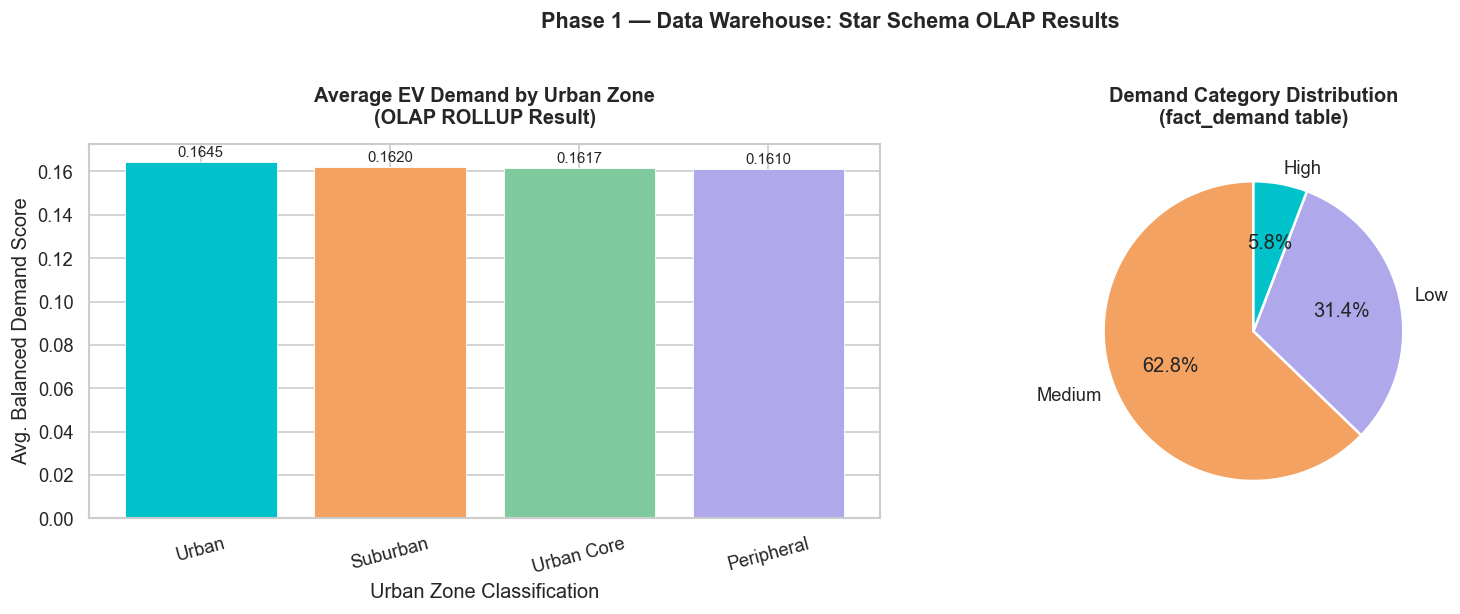

Star schema diagram saved.


In [6]:
# ── Visualise Star Schema Structure ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OLAP rollup bar chart
rollup_plot = rollup[rollup['urban_zone'] != 'ALL ZONES'].copy()
colors = ['#00C2CB', '#F4A261', '#7ECA9C', '#AFA9EC']
bars = axes[0].bar(rollup_plot['urban_zone'], rollup_plot['avg_balanced_demand'],
                   color=colors[:len(rollup_plot)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Average EV Demand by Urban Zone\n(OLAP ROLLUP Result)', fontweight='bold', pad=12)
axes[0].set_xlabel('Urban Zone Classification')
axes[0].set_ylabel('Avg. Balanced Demand Score')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# Demand category distribution
demand_dist = con.execute("""
    SELECT demand_category, COUNT(*) as cnt FROM fact_demand GROUP BY demand_category
""").df()
pie_colors = {'High': '#00C2CB', 'Medium': '#F4A261', 'Low': '#AFA9EC'}
axes[1].pie(
    demand_dist['cnt'],
    labels=demand_dist['demand_category'],
    colors=[pie_colors[c] for c in demand_dist['demand_category']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Demand Category Distribution\n(fact_demand table)', fontweight='bold', pad=12)

plt.suptitle('Phase 1 — Data Warehouse: Star Schema OLAP Results', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('phase1_data_warehouse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Star schema diagram saved.')

---
# Phase 2 — Data Preprocessing & Feature Engineering
**DWDM Module 1 — Data Preprocessing**

In [7]:
print('Phase 2: Data Cleaning & Feature Engineering')
print('=' * 55)

df = df_raw.copy()
before_count = len(df)

# ── Step 1: Zero-Inflation Report ────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_pct = (df[numeric_cols] == 0).mean() * 100
sparse_features = zero_pct[zero_pct > 50].sort_values(ascending=False)
print(f'Features with >50% zero values: {len(sparse_features)}')
print(sparse_features.to_string())

# ── Step 2: Remove Empty/Ocean Zones ─────────────────────────────
valid_mask = (
    (df.get('road_density_total', pd.Series(0, index=df.index)) > 0.01) |
    (df.get('poi_density_commercial', pd.Series(0, index=df.index)) > 0) |
    (df.get('poi_density_residential', pd.Series(0, index=df.index)) > 0)
)
df = df[valid_mask].copy()
print(f'\nRows removed (empty zones): {before_count - len(df):,}')
print(f'Valid rows remaining: {len(df):,}')

# ── Step 3: Feature Engineering ──────────────────────────────────
# Land-use entropy (Shannon entropy of POI proportions)
poi_cols = [
    'poi_density_commercial', 'poi_density_residential',
    'poi_density_industrial', 'poi_density_recreational',
    'poi_density_transport_hub'
]
existing_poi = [c for c in poi_cols if c in df.columns]
df['total_poi'] = df[existing_poi].sum(axis=1) + 1e-9
proportions = df[existing_poi].div(df['total_poi'], axis=0)
df['land_use_entropy'] = -(proportions * np.log(proportions + 1e-10)).sum(axis=1)

# Accessibility composite score
df['accessibility_score'] = (
    df.get('road_density_total', 0) * 0.4 +
    df.get('public_transport_access', 0) * 0.3 +
    df.get('pedestrian_infrastructure', 0) * 0.3
)

# Commercial gravity (weighted POI sum)
df['commercial_gravity'] = (
    df.get('poi_density_commercial', 0) * 0.5 +
    df.get('poi_density_transport_hub', 0) * 0.3 +
    df.get('poi_density_recreational', 0) * 0.2
)

print(f'\nNew features engineered: land_use_entropy, accessibility_score, commercial_gravity')
print(f'Final feature count: {df.shape[1]}')
print('\nSample of engineered features:')
print(df[['land_use_entropy', 'accessibility_score', 'commercial_gravity']].describe().round(4))

Phase 2: Data Cleaning & Feature Engineering
Features with >50% zero values: 21
closeness_centrality_avg      100.000000
degree_centrality_avg         100.000000
betweenness_centrality_avg    100.000000
poi_density_government         92.218011
poi_density_healthcare         92.203821
grid_variation_x               76.569381
grid_variation_y               76.569381
poi_density_commercial         75.024466
poi_density_recreational       73.380383
poi_density_education          70.791606
poi_density_industrial         68.163032
road_density_secondary         67.273955
road_density_primary           66.790843
offset_y_km                    65.006328
offset_x_km                    65.006328
public_transport_access        59.157277
poi_density_transport_hub      59.157277
poi_density_residential        57.964176
mixed_use_index                55.260574
pedestrian_infrastructure      54.993411
road_density_tertiary          54.993411

Rows removed (empty zones): 255,478
Valid rows remaining: 

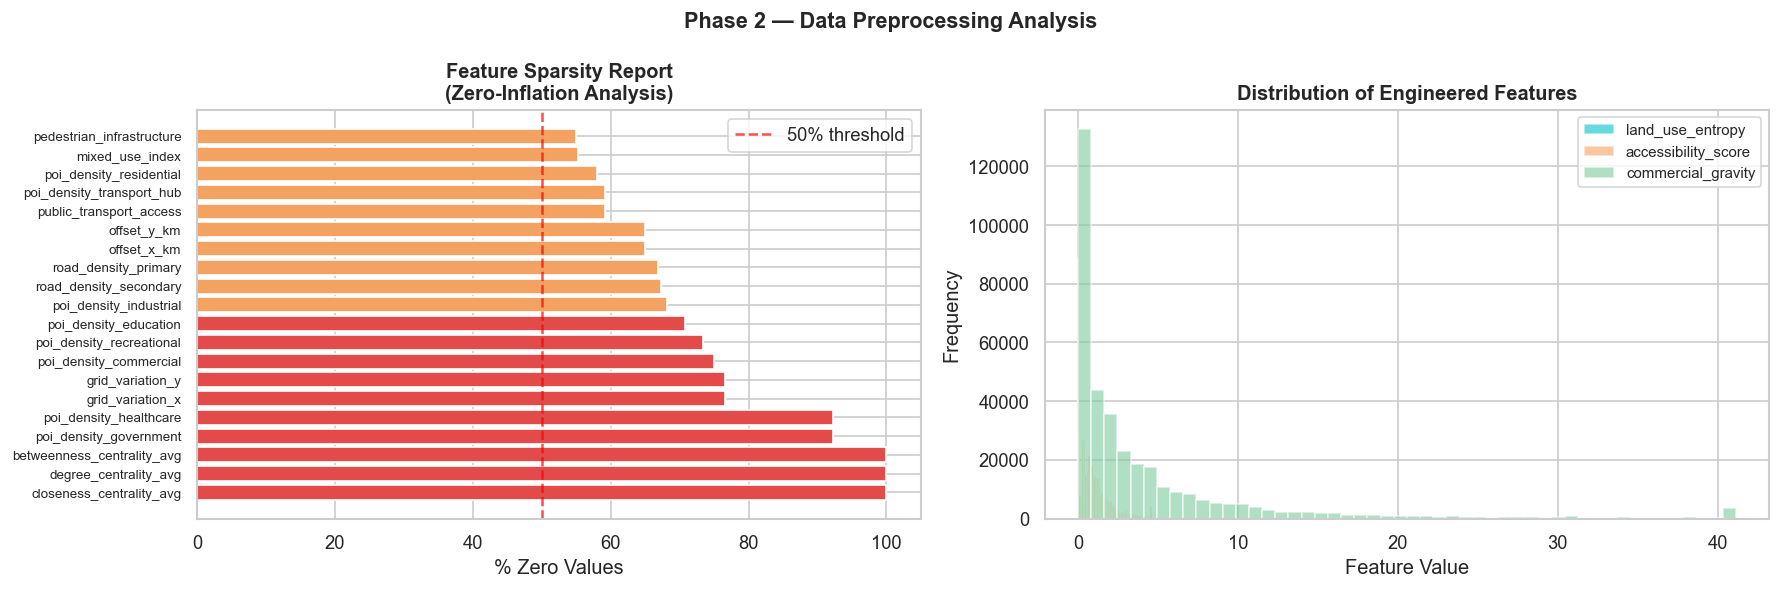

In [8]:
# ── Zero-Inflation Visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sparsity heatmap (top 20 most sparse features)
top_sparse = zero_pct.sort_values(ascending=False).head(20)
colors_sparse = ['#E24B4A' if v > 70 else '#F4A261' if v > 50 else '#00C2CB'
                 for v in top_sparse.values]
axes[0].barh(range(len(top_sparse)), top_sparse.values, color=colors_sparse)
axes[0].set_yticks(range(len(top_sparse)))
axes[0].set_yticklabels(top_sparse.index, fontsize=8)
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
axes[0].set_xlabel('% Zero Values')
axes[0].set_title('Feature Sparsity Report\n(Zero-Inflation Analysis)', fontweight='bold')
axes[0].legend()

# Engineered feature distributions
for i, feat in enumerate(['land_use_entropy', 'accessibility_score', 'commercial_gravity']):
    axes[1].hist(df[feat].clip(0, df[feat].quantile(0.99)),
                 bins=50, alpha=0.6,
                 color=['#00C2CB', '#F4A261', '#7ECA9C'][i],
                 label=feat)
axes[1].set_title('Distribution of Engineered Features', fontweight='bold')
axes[1].set_xlabel('Feature Value')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 2 — Data Preprocessing Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 3 — EDA: Correlation Deep-Dive
**DWDM Module 2 — Data Mining Concepts**

In [9]:
print('Phase 3: Exploratory Data Analysis — Correlation Analysis')
print('=' * 60)

demand_cols = [
    'demand_score_hours_only', 'demand_score_kwh25_hrs75',
    'demand_score_balanced', 'demand_score_kwh75_hrs25',
    'demand_score_kwh_only'
]
feature_cols = [
    'poi_density_commercial', 'poi_density_residential',
    'poi_density_industrial', 'poi_density_transport_hub',
    'poi_density_recreational', 'road_density_primary',
    'road_density_secondary', 'road_density_total',
    'intersection_density', 'urban_centrality_score',
    'land_use_entropy', 'accessibility_score',
    'commercial_gravity', 'mixed_use_index'
]
feature_cols = [c for c in feature_cols if c in df.columns]
analysis_cols = feature_cols + demand_cols

# Sample for correlation (full 600K is slow)
sample = df[analysis_cols].dropna().sample(min(50000, len(df)), random_state=42)

# Pearson & Spearman correlations
pearson_corr  = sample.corr(method='pearson')
spearman_corr = sample.corr(method='spearman')

# Top features per demand score (Pearson)
print('\nTop 5 predictors per demand score (Pearson |r|):')
print('-' * 50)
for dc in demand_cols:
    top = pearson_corr[dc].drop(demand_cols).abs().nlargest(5)
    print(f'\n{dc}:')
    for feat, val in top.items():
        direction = '+' if pearson_corr[dc][feat] > 0 else '-'
        print(f'  {direction}{val:.4f}  {feat}')

Phase 3: Exploratory Data Analysis — Correlation Analysis

Top 5 predictors per demand score (Pearson |r|):
--------------------------------------------------

demand_score_hours_only:
  -0.0322  poi_density_recreational
  +0.0240  road_density_secondary
  -0.0227  poi_density_transport_hub
  -0.0225  poi_density_residential
  -0.0208  mixed_use_index

demand_score_kwh25_hrs75:
  -0.0409  poi_density_recreational
  -0.0284  commercial_gravity
  -0.0261  poi_density_residential
  -0.0257  poi_density_transport_hub
  -0.0256  mixed_use_index

demand_score_balanced:
  -0.0514  poi_density_recreational
  -0.0398  commercial_gravity
  -0.0349  poi_density_commercial
  -0.0313  mixed_use_index
  -0.0304  urban_centrality_score

demand_score_kwh75_hrs25:
  -0.0590  poi_density_recreational
  -0.0500  commercial_gravity
  -0.0469  poi_density_commercial
  -0.0438  urban_centrality_score
  -0.0349  mixed_use_index

demand_score_kwh_only:
  -0.0563  poi_density_recreational
  -0.0518  commercial

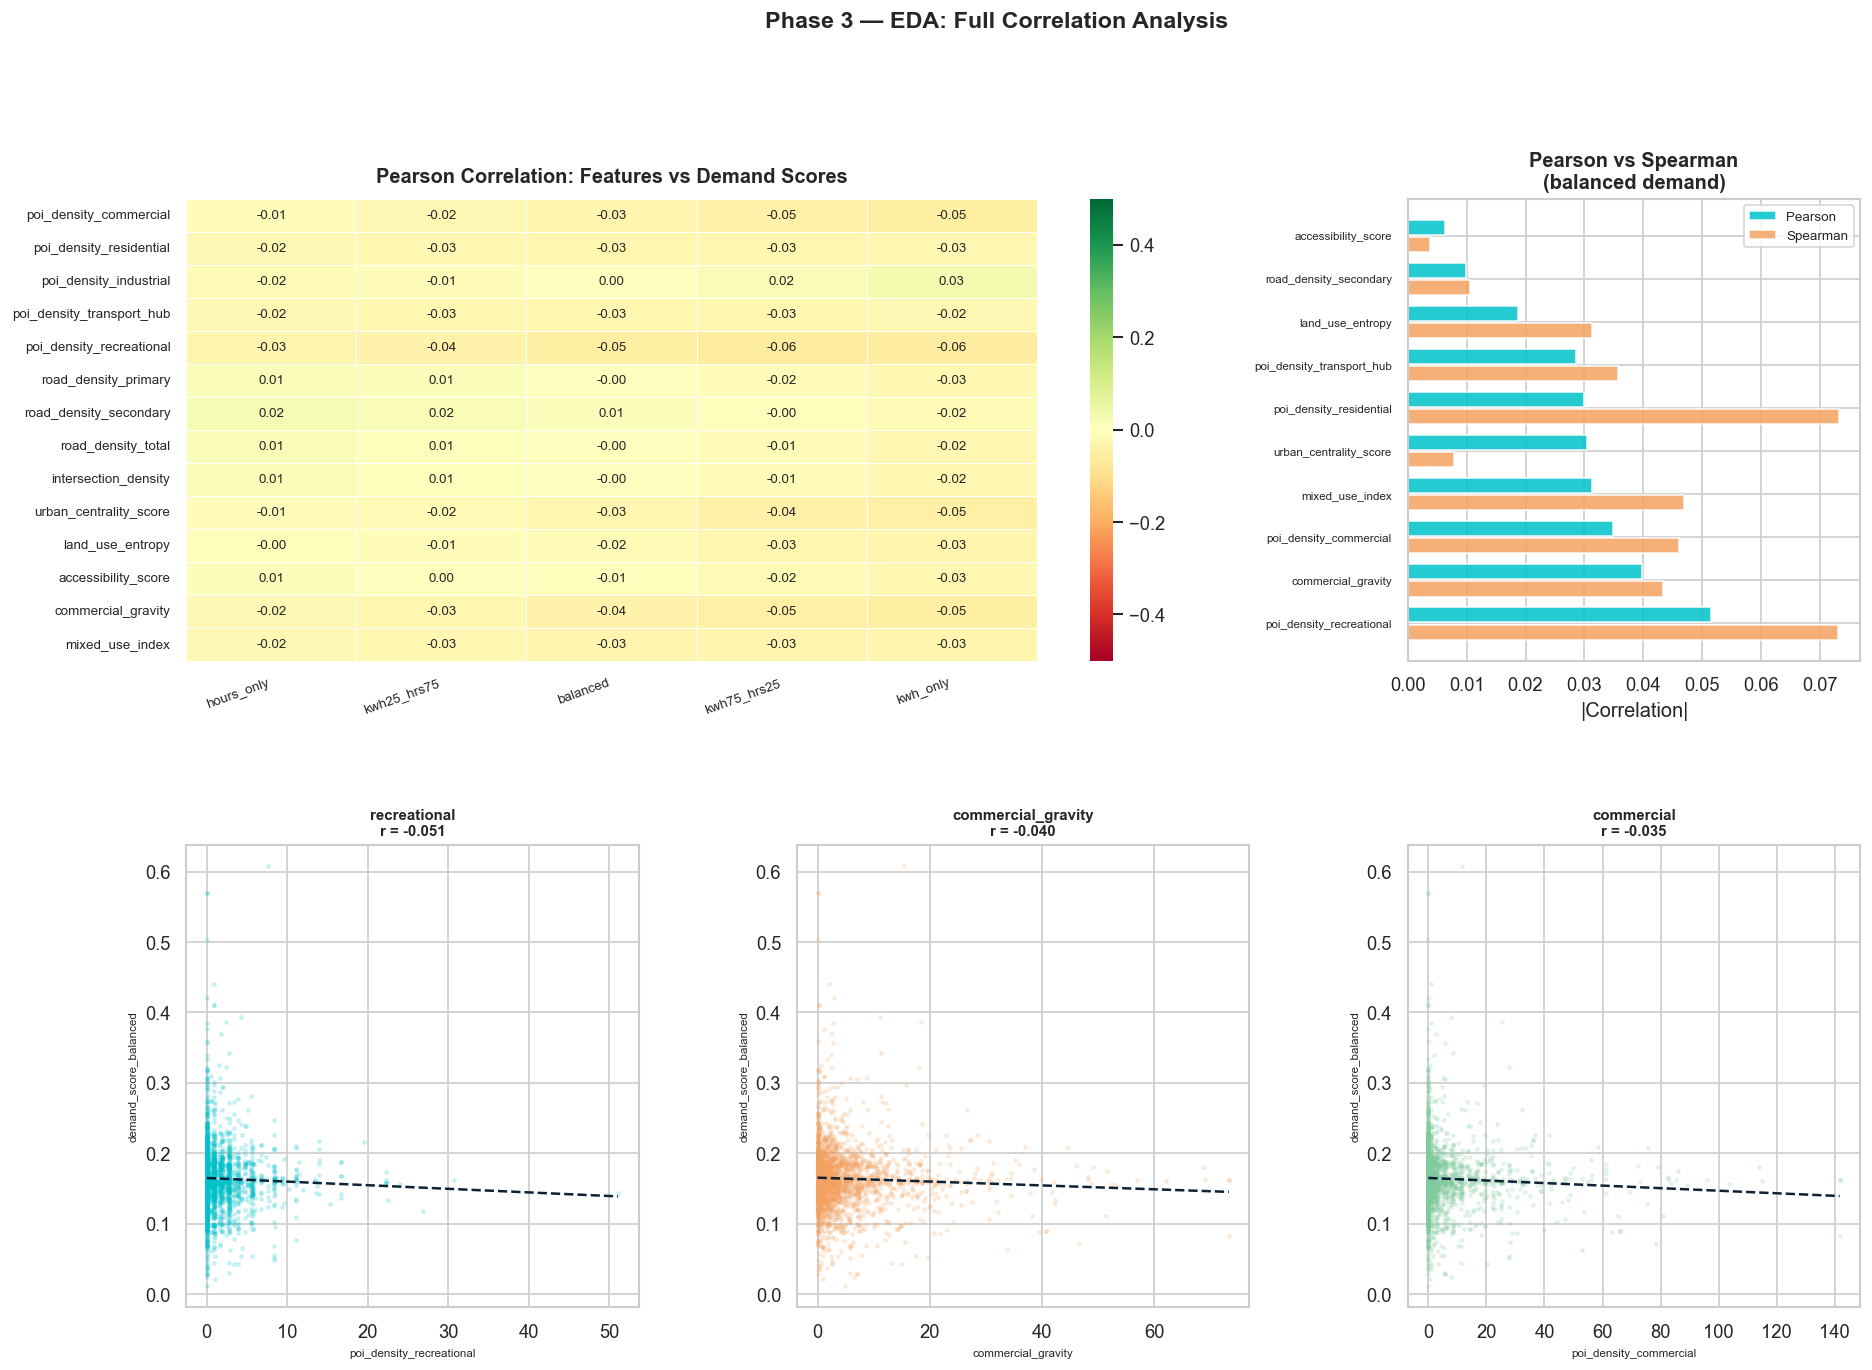

In [10]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Pearson heatmap (features vs demand) ─────────────────
ax1 = fig.add_subplot(gs[0, :2])
feat_demand_pearson = pearson_corr.loc[feature_cols, demand_cols]
sns.heatmap(
    feat_demand_pearson,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.3, ax=ax1,
    annot_kws={'size': 8}
)
ax1.set_title('Pearson Correlation: Features vs Demand Scores', fontweight='bold', pad=10)
ax1.set_xticklabels([d.replace('demand_score_', '') for d in demand_cols], rotation=20, ha='right', fontsize=8)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=8)

# ── Plot 2: Pearson vs Spearman comparison (balanced demand) ─────
ax2 = fig.add_subplot(gs[0, 2])
target = 'demand_score_balanced'
p_vals = pearson_corr[target].drop(demand_cols).abs().nlargest(10)
s_vals = spearman_corr[target].drop(demand_cols).abs().reindex(p_vals.index)
x = range(len(p_vals))
ax2.barh([i + 0.2 for i in x], p_vals.values, height=0.35,
         color='#00C2CB', label='Pearson', alpha=0.85)
ax2.barh([i - 0.2 for i in x], s_vals.values, height=0.35,
         color='#F4A261', label='Spearman', alpha=0.85)
ax2.set_yticks(list(x))
ax2.set_yticklabels(p_vals.index, fontsize=7)
ax2.set_title('Pearson vs Spearman\n(balanced demand)', fontweight='bold')
ax2.set_xlabel('|Correlation|')
ax2.legend(fontsize=8)

# ── Plot 3–5: Scatter plots (top 3 features vs balanced demand) ──
top3 = pearson_corr[target].drop(demand_cols).abs().nlargest(3).index
scatter_colors = ['#00C2CB', '#F4A261', '#7ECA9C']
for i, feat in enumerate(top3):
    ax = fig.add_subplot(gs[1, i])
    scatter_sample = sample[[feat, target]].sample(3000, random_state=42)
    ax.scatter(scatter_sample[feat], scatter_sample[target],
               alpha=0.15, s=4, color=scatter_colors[i])
    # Trend line
    z = np.polyfit(scatter_sample[feat], scatter_sample[target], 1)
    p = np.poly1d(z)
    x_line = np.linspace(scatter_sample[feat].min(), scatter_sample[feat].max(), 100)
    ax.plot(x_line, p(x_line), color='#0D2137', linewidth=1.5, linestyle='--')
    r = pearson_corr[target][feat]
    ax.set_title(f'{feat.replace("poi_density_","").replace("road_density_","road_")}\nr = {r:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=7)
    ax.set_ylabel('demand_score_balanced', fontsize=7)

plt.suptitle('Phase 3 — EDA: Full Correlation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('phase3_eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 4 — Outlier Detection: Isolation Forest + LOF
**DWDM Module 6 — Outlier Analysis**  
Both distance-based (LOF) and density-based (Isolation Forest) methods implemented.

In [11]:
print('Phase 4: Outlier Detection')
print('=' * 40)

outlier_features = [c for c in feature_cols if c in df.columns]
X_outlier = df[outlier_features].fillna(0)

# Use a sample for speed (LOF is O(n²))
sample_idx = X_outlier.sample(min(30000, len(X_outlier)), random_state=42).index
X_sample = X_outlier.loc[sample_idx]

# ── Method 1: Isolation Forest ───────────────────────────────────
print('Running Isolation Forest...')
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_sample)  # -1 = anomaly, 1 = normal
iso_scores = iso.decision_function(X_sample)
iso_anomalies = (iso_labels == -1).sum()
print(f'  Isolation Forest anomalies detected: {iso_anomalies:,} ({iso_anomalies/len(X_sample)*100:.1f}%)')

# ── Method 2: Local Outlier Factor ───────────────────────────────
print('Running Local Outlier Factor (LOF)...')
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
lof_labels = lof.fit_predict(X_sample)  # -1 = anomaly, 1 = normal
lof_scores = lof.negative_outlier_factor_
lof_anomalies = (lof_labels == -1).sum()
print(f'  LOF anomalies detected: {lof_anomalies:,} ({lof_anomalies/len(X_sample)*100:.1f}%)')

# Agreement between both methods
both_anomaly = ((iso_labels == -1) & (lof_labels == -1)).sum()
either_anomaly = ((iso_labels == -1) | (lof_labels == -1)).sum()
print(f'\n  Agreed anomalies (both methods): {both_anomaly:,}')
print(f'  Agreement rate: {both_anomaly/either_anomaly*100:.1f}%')

# Apply filter: remove rows flagged by BOTH methods
full_iso = iso.fit_predict(X_outlier)
df['is_outlier'] = (full_iso == -1)
df_clean = df[~df['is_outlier']].copy()
print(f'\n  Rows removed (outliers): {df["is_outlier"].sum():,}')
print(f'  Clean dataset size: {len(df_clean):,}')

Phase 4: Outlier Detection
Running Isolation Forest...
  Isolation Forest anomalies detected: 1,494 (5.0%)
Running Local Outlier Factor (LOF)...
  LOF anomalies detected: 1,499 (5.0%)

  Agreed anomalies (both methods): 180
  Agreement rate: 6.4%

  Rows removed (outliers): 17,854
  Clean dataset size: 339,776


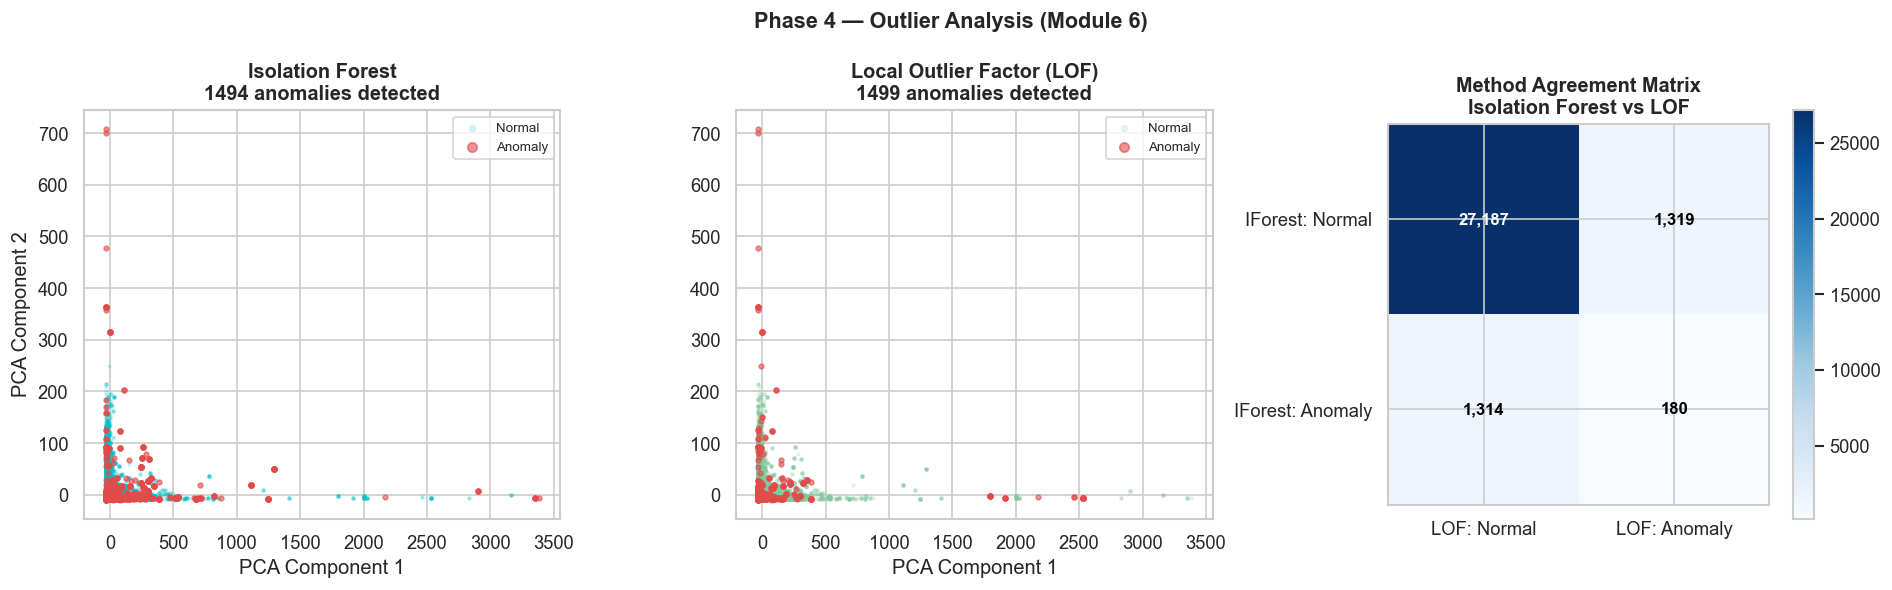

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PCA projection for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample.fillna(0))

# IForest scatter
axes[0].scatter(X_pca[iso_labels == 1, 0],  X_pca[iso_labels == 1, 1],
                c='#00C2CB', alpha=0.15, s=3, label='Normal')
axes[0].scatter(X_pca[iso_labels == -1, 0], X_pca[iso_labels == -1, 1],
                c='#E24B4A', alpha=0.6, s=8, label='Anomaly')
axes[0].set_title(f'Isolation Forest\n{iso_anomalies} anomalies detected', fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)
axes[0].set_xlabel('PCA Component 1'); axes[0].set_ylabel('PCA Component 2')

# LOF scatter
axes[1].scatter(X_pca[lof_labels == 1, 0],  X_pca[lof_labels == 1, 1],
                c='#7ECA9C', alpha=0.15, s=3, label='Normal')
axes[1].scatter(X_pca[lof_labels == -1, 0], X_pca[lof_labels == -1, 1],
                c='#E24B4A', alpha=0.6, s=8, label='Anomaly')
axes[1].set_title(f'Local Outlier Factor (LOF)\n{lof_anomalies} anomalies detected', fontweight='bold')
axes[1].legend(fontsize=8, markerscale=2)
axes[1].set_xlabel('PCA Component 1')

# Comparison: agreement matrix
agree_matrix = np.array([
    [(iso_labels == 1) & (lof_labels == 1),   (iso_labels == 1) & (lof_labels == -1)],
    [(iso_labels == -1) & (lof_labels == 1),  (iso_labels == -1) & (lof_labels == -1)]
])
agree_counts = [[s.sum() for s in row] for row in agree_matrix]
im = axes[2].imshow(agree_counts, cmap='Blues')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['LOF: Normal', 'LOF: Anomaly'])
axes[2].set_yticklabels(['IForest: Normal', 'IForest: Anomaly'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{agree_counts[i][j]:,}', ha='center', va='center',
                     fontweight='bold', fontsize=10,
                     color='white' if agree_counts[i][j] > max(max(r) for r in agree_counts)/2 else 'black')
axes[2].set_title('Method Agreement Matrix\nIsolation Forest vs LOF', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.suptitle('Phase 4 — Outlier Analysis (Module 6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase4_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 5 — Frequent Pattern Mining: Apriori on POI Co-occurrence
**DWDM Module 3 — Frequent Pattern Mining** ← *This closes the syllabus gap!*

**Research question:** In high-demand EV charging zones, which types of Points of Interest
appear together most frequently? What association rules can we derive?

In [13]:
print('Phase 5: Apriori Association Rule Mining on POI Co-occurrence')
print('=' * 65)

# ── Work on HIGH-DEMAND zones only ───────────────────────────────
high_demand_threshold = df_clean['demand_score_balanced'].quantile(0.75)
high_demand_zones = df_clean[df_clean['demand_score_balanced'] >= high_demand_threshold].copy()
print(f'High-demand zones (top 25%): {len(high_demand_zones):,}')
print(f'Threshold: {high_demand_threshold:.4f}')

# ── Build binary transaction matrix ──────────────────────────────
# Each row = one grid cell. Each column = one POI type.
# Value = 1 if that POI type is present in the cell (density > 0)
poi_binary_cols = [
    'poi_density_commercial', 'poi_density_residential',
    'poi_density_industrial', 'poi_density_recreational',
    'poi_density_transport_hub', 'poi_density_education',
    'poi_density_healthcare'
]
poi_binary_cols = [c for c in poi_binary_cols if c in high_demand_zones.columns]

# Clean column names for readability
short_names = {
    'poi_density_commercial':   'Commercial',
    'poi_density_residential':  'Residential',
    'poi_density_industrial':   'Industrial',
    'poi_density_recreational': 'Recreational',
    'poi_density_transport_hub':'TransitHub',
    'poi_density_education':    'Education',
    'poi_density_healthcare':   'Healthcare'
}

# Binary encoding: 1 = present, 0 = absent
binary_df = (high_demand_zones[poi_binary_cols] > 0).astype(bool)
binary_df.columns = [short_names[c] for c in poi_binary_cols]

# Sample for performance
binary_sample = binary_df.sample(min(20000, len(binary_df)), random_state=42)

print(f'\nTransaction matrix shape: {binary_sample.shape}')
print('\nPOI presence rate in high-demand zones:')
print((binary_sample.mean() * 100).round(1).to_string())

# ── Run Apriori ──────────────────────────────────────────────────
print('\nRunning Apriori algorithm...')
freq_itemsets = apriori(
    binary_sample,
    min_support=0.15,
    use_colnames=True,
    max_len=3
)
freq_itemsets['length'] = freq_itemsets['itemsets'].apply(len)
print(f'Frequent itemsets found: {len(freq_itemsets)}')
print(f'  - 1-itemsets: {(freq_itemsets.length==1).sum()}')
print(f'  - 2-itemsets: {(freq_itemsets.length==2).sum()}')
print(f'  - 3-itemsets: {(freq_itemsets.length==3).sum()}')

# ── Generate Association Rules ────────────────────────────────────
rules = association_rules(
    freq_itemsets,
    metric='lift',
    min_threshold=1.1
)
rules = rules.sort_values('lift', ascending=False)
print(f'\nAssociation rules found: {len(rules)}')
print('\nTop 10 rules by lift:')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

Phase 5: Apriori Association Rule Mining on POI Co-occurrence
High-demand zones (top 25%): 84,948
Threshold: 0.1830

Transaction matrix shape: (20000, 7)

POI presence rate in high-demand zones:
Commercial      37.6
Residential     68.7
Industrial      52.5
Recreational    37.3
TransitHub      66.0
Education       48.6
Healthcare      12.9

Running Apriori algorithm...
Frequent itemsets found: 40
  - 1-itemsets: 6
  - 2-itemsets: 15
  - 3-itemsets: 19

Association rules found: 144

Top 10 rules by lift:
                           antecedents                            consequents  support  confidence     lift
  frozenset({Recreational, Education})                frozenset({Commercial})  0.18190    0.693349 1.842787
               frozenset({Commercial})   frozenset({Recreational, Education})  0.18190    0.483455 1.842787
             frozenset({Recreational})     frozenset({Commercial, Education})  0.18190    0.487276 1.790138
    frozenset({Commercial, Education})              frozens

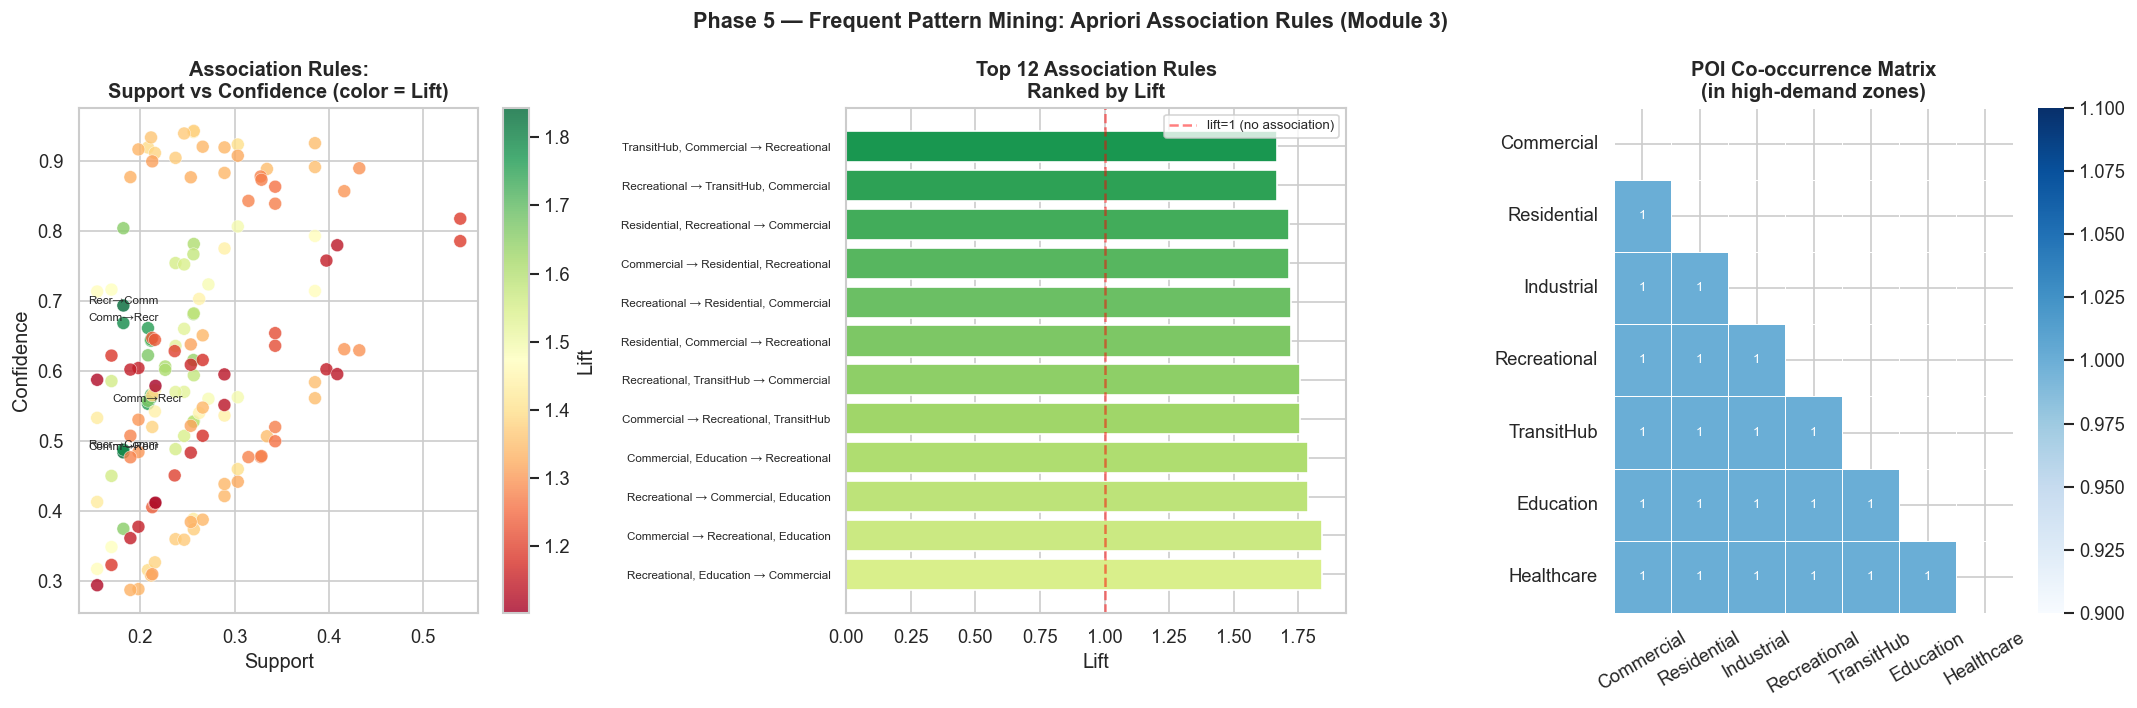


Key insight from association rules:
  Strongest rule: {'Recreational', 'Education'} → {'Commercial'}
  Support: 0.182 | Confidence: 0.693 | Lift: 1.843


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Support vs Confidence coloured by Lift ───────────────
scatter = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', s=60,
    alpha=0.8, edgecolors='white', linewidth=0.3
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules:\nSupport vs Confidence (color = Lift)', fontweight='bold')

# Label top 5 rules
for _, row in rules.head(5).iterrows():
    label = f"{list(row['antecedents'])[0][:4]}→{list(row['consequents'])[0][:4]}"
    axes[0].annotate(label, (row['support'], row['confidence']),
                     fontsize=7, ha='center', va='bottom')

# ── Plot 2: Top rules bar chart (lift) ───────────────────────────
top_rules = rules.head(12).copy()
top_rules['rule_label'] = top_rules.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}", axis=1
)

bar_colors = plt.cm.RdYlGn(np.linspace(0.6, 0.9, len(top_rules)))

axes[1].barh(range(len(top_rules)), top_rules['lift'].values,
             color=bar_colors, edgecolor='white')

axes[1].set_yticks(range(len(top_rules)))
axes[1].set_yticklabels(top_rules['rule_label'], fontsize=7)
axes[1].axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='lift=1 (no association)')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 12 Association Rules\nRanked by Lift', fontweight='bold')
axes[1].legend(fontsize=8)

# ── Plot 3: Co-occurrence heatmap ────────────────────────────────
cooccurrence = binary_sample.T.dot(binary_sample).to_numpy().copy()
np.fill_diagonal(cooccurrence, 0)

mask = np.zeros_like(cooccurrence, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    cooccurrence, mask=mask,
    xticklabels=binary_sample.columns,
    yticklabels=binary_sample.columns,
    annot=True, fmt='g', cmap='Blues',
    ax=axes[2], linewidths=0.3,
    annot_kws={'size': 8}
)

axes[2].set_title('POI Co-occurrence Matrix\n(in high-demand zones)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].tick_params(axis='y', rotation=0)

# ── Final layout ────────────────────────────────────────────────
plt.suptitle('Phase 5 — Frequent Pattern Mining: Apriori Association Rules (Module 3)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('phase5_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Insight ─────────────────────────────────────────────────────
print('\nKey insight from association rules:')
if len(rules) > 0:
    top = rules.iloc[0]
    print(f'  Strongest rule: {set(top["antecedents"])} → {set(top["consequents"])}')
    print(f'  Support: {top["support"]:.3f} | Confidence: {top["confidence"]:.3f} | Lift: {top["lift"]:.3f}')

---
# Phase 6 — Feature Selection
**DWDM Module 2 — Data Mining Concepts**

Phase 6: Feature Selection
Original columns: 48
Dropped: 30
Final predictors: 18

Final feature list:
   1. poi_density_commercial
   2. poi_density_residential
   3. poi_density_industrial
   4. poi_density_recreational
   5. poi_density_healthcare
   6. poi_density_education
   7. poi_density_government
   8. poi_density_transport_hub
   9. road_density_total
  10. intersection_density
  11. road_connectivity_index
  12. urban_density_proxy
  13. pedestrian_infrastructure
  14. public_transport_access
  15. land_use_entropy
  16. urban_centrality_score
  17. accessibility_score
  18. commercial_gravity

Computing Random Forest feature importance...

Top 8 features by importance:
poi_density_recreational     0.157284
poi_density_residential      0.114369
poi_density_education        0.099009
intersection_density         0.086011
road_density_total           0.085563
commercial_gravity           0.063002
accessibility_score          0.059937
poi_density_transport_hub    0.051236


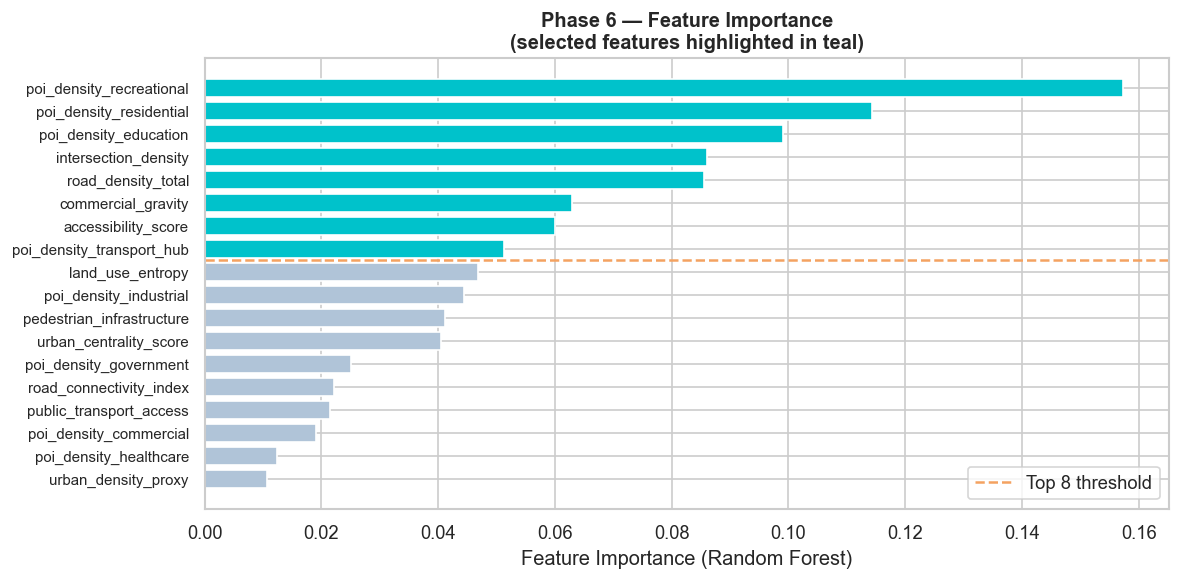

In [15]:
print('Phase 6: Feature Selection')
print('=' * 40)

# ── Drop leakage, metadata, and redundant columns ─────────────────
targets_and_leakage = [
    'demand_score_kwh_only', 'demand_score_hours_only',
    'demand_score_kwh25_hrs75', 'demand_score_balanced',
    'demand_score_kwh75_hrs25', 'charging_suitability_index'
]
grid_meta = [c for c in df_clean.columns if re.search(r'grid|offset|size_scale', c, re.I)]
coordinates = ['latitude_x', 'longitude_x', 'latitude_y', 'longitude_y', 'actual_size_km']
redundant = ['road_density_primary', 'road_density_secondary', 'road_density_tertiary',
             'betweenness_centrality_avg', 'closeness_centrality_avg',
             'degree_centrality_avg', 'mixed_use_index', 'is_outlier', 'total_poi']

all_drop = list(set(targets_and_leakage + grid_meta + coordinates + redundant))
all_drop = [c for c in all_drop if c in df_clean.columns]

# Final features
y = df_clean['demand_score_balanced'].fillna(0)
X = df_clean.drop(columns=all_drop, errors='ignore')
X = X.select_dtypes(include=[np.number]).fillna(0)

print(f'Original columns: {df_clean.shape[1]}')
print(f'Dropped: {len(all_drop)}')
print(f'Final predictors: {X.shape[1]}')
print(f'\nFinal feature list:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

# ── Random Forest feature importance ─────────────────────────────
print('\nComputing Random Forest feature importance...')
X_sample_fs = X.sample(min(50000, len(X)), random_state=42)
y_sample_fs = y.loc[X_sample_fs.index]

rf_selector = RandomForestRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
rf_selector.fit(X_sample_fs, y_sample_fs)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Select top N features
TOP_N = 8
valid_feats = importances.head(TOP_N).index.tolist()
print(f'\nTop {TOP_N} features by importance:')
print(importances.head(TOP_N).to_string())

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#00C2CB' if i < TOP_N else '#B0C4D8' for i in range(len(importances))]
ax.barh(range(len(importances)), importances.values[::-1], color=colors[::-1])
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index[::-1], fontsize=9)
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title('Phase 6 — Feature Importance\n(selected features highlighted in teal)', fontweight='bold')
ax.axhline(y=len(importances)-TOP_N-0.5, color='#F4A261', linestyle='--',
           linewidth=1.5, label=f'Top {TOP_N} threshold')
ax.legend()
plt.tight_layout()
plt.savefig('phase6_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 7 — ML Model Training: 4-Model Benchmark + SHAP
**DWDM Module 4 — Classification & Prediction**

Training four models, comparing all metrics, then explaining predictions with SHAP.

In [16]:
print('Phase 7: Model Training & Benchmarking')
print('=' * 45)

# ── Prepare data ─────────────────────────────────────────────────
X_model = df_clean[valid_feats].fillna(0)
y_class = pd.qcut(y, q=3, labels=[0, 1, 2])  # Low=0, Medium=1, High=2
y_class = y_class.fillna(0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_class, test_size=0.2, random_state=42, stratify=y_class
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Class distribution: {pd.Series(y_train).value_counts().sort_index().to_dict()}')

# ── Define 4 models ──────────────────────────────────────────────
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    'XGB + RF Ensemble': VotingClassifier(
        estimators=[
            ('xgb', xgb.XGBClassifier(
                objective='multi:softmax', num_class=3,
                n_estimators=100, max_depth=6, n_jobs=-1,
                random_state=42, use_label_encoder=False, eval_metric='mlogloss'
            )),
            ('rf', RandomForestClassifier(
                n_estimators=100, max_depth=8, n_jobs=-1, random_state=42
            ))
        ],
        voting='soft'
    )
}

# ── Train & Evaluate ─────────────────────────────────────────────
results = {}
trained_models = {}

for name, model in models.items():
    print(f'\nTraining: {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'F1 (weighted)': f1,
                     'Precision': prec, 'Recall': rec,
                     'y_pred': y_pred, 'cm': confusion_matrix(y_test, y_pred)}
    trained_models[name] = model

    print(f'  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  Baseline (random): 0.3333')

# Store our main model
model = trained_models['XGB + RF Ensemble']

Phase 7: Model Training & Benchmarking
Train: 271,820  |  Test: 67,956
Class distribution: {0: 90612, 1: 90601, 2: 90607}

Training: Decision Tree...
  Accuracy: 0.4105  |  F1: 0.3811  |  Baseline (random): 0.3333

Training: Naive Bayes...
  Accuracy: 0.3499  |  F1: 0.2812  |  Baseline (random): 0.3333

Training: Random Forest...
  Accuracy: 0.4412  |  F1: 0.4301  |  Baseline (random): 0.3333

Training: XGB + RF Ensemble...
  Accuracy: 0.5073  |  F1: 0.5028  |  Baseline (random): 0.3333



=== MODEL COMPARISON TABLE ===
                   Accuracy  F1 (weighted)  Precision  Recall
Decision Tree        0.4105         0.3811     0.4338  0.4105
Naive Bayes          0.3499         0.2812     0.3674  0.3499
Random Forest        0.4412         0.4301     0.4523  0.4412
XGB + RF Ensemble    0.5073         0.5028     0.5094  0.5073

Baseline (random 3-class): 0.3333


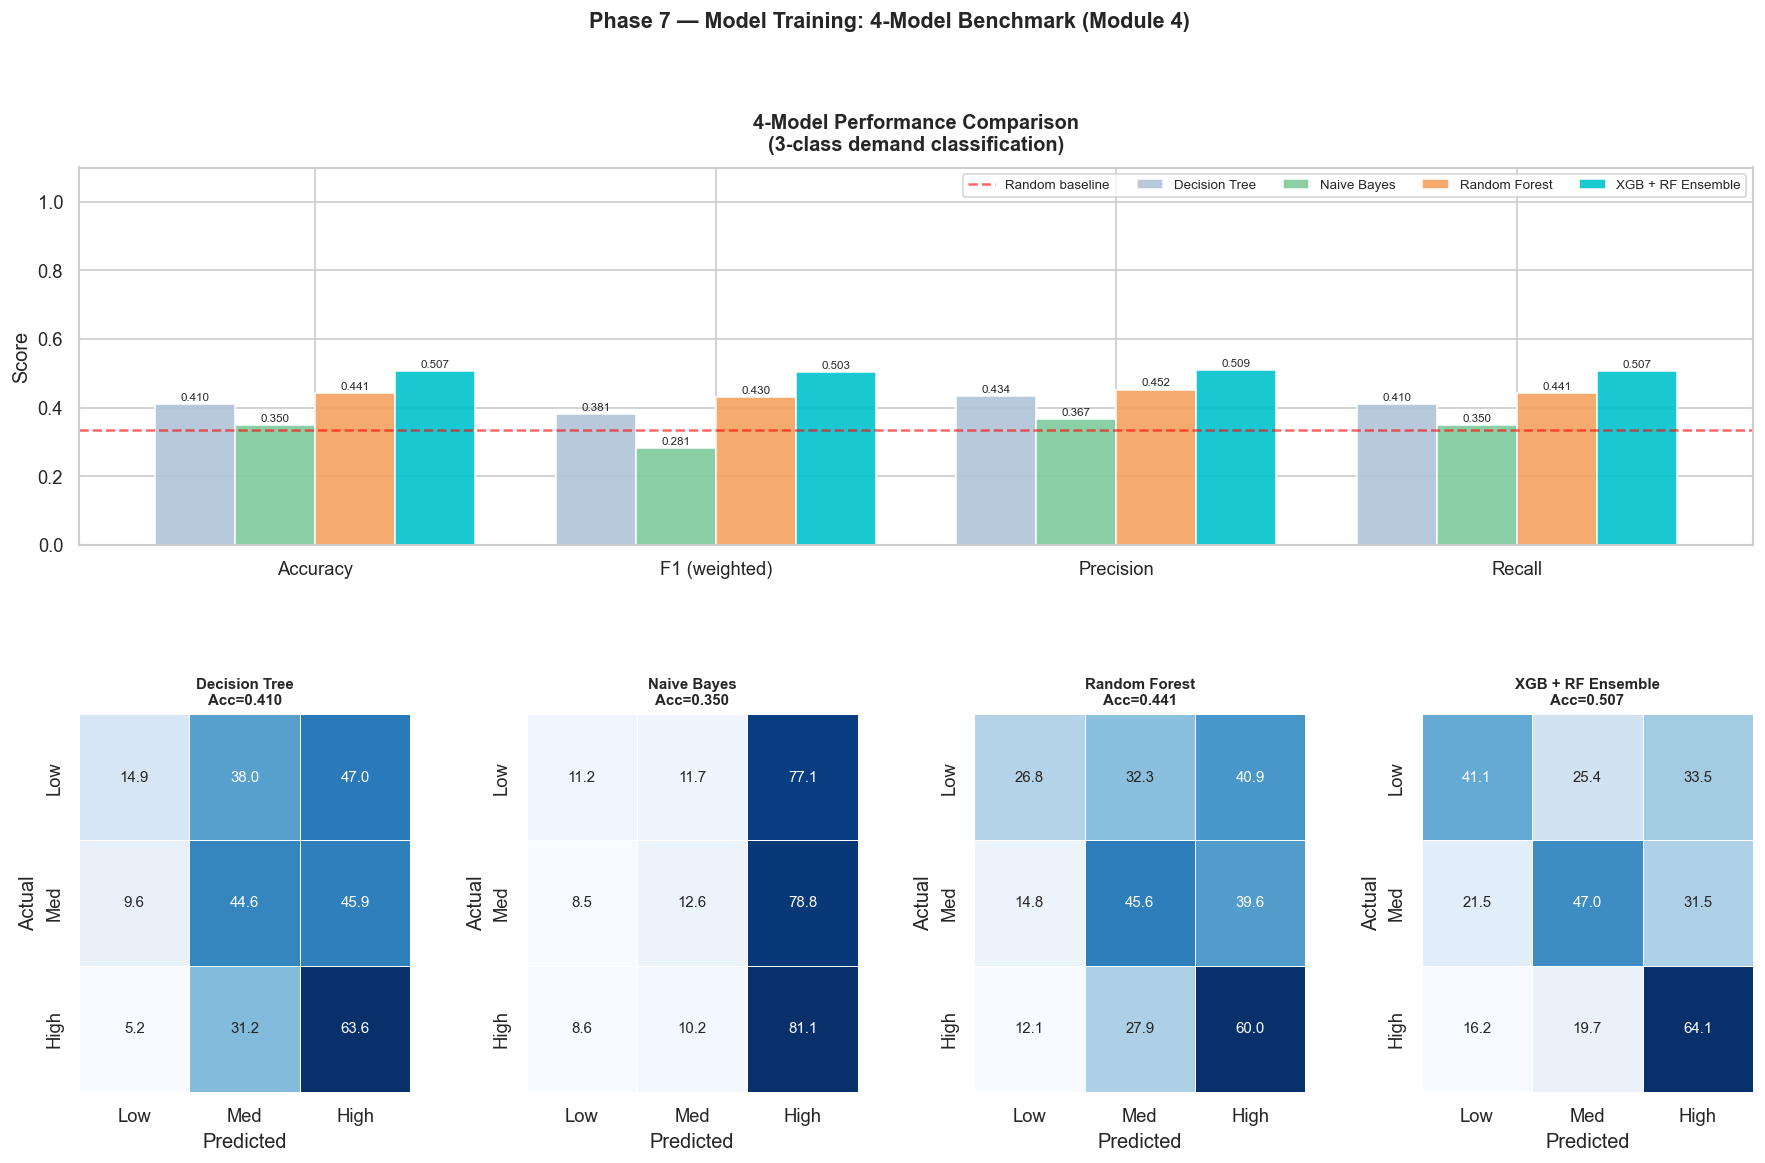

In [17]:
# ── Comparison Table ─────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['y_pred', 'cm']}
    for name, res in results.items()
}).T

print('\n=== MODEL COMPARISON TABLE ===')
print(metrics_df.round(4).to_string())
print(f'\nBaseline (random 3-class): 0.3333')

# ── Visualise: Comparison + Confusion Matrices ───────────────────
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# Metrics bar chart
ax_metrics = fig.add_subplot(gs[0, :])
metric_names = ['Accuracy', 'F1 (weighted)', 'Precision', 'Recall']
x = np.arange(len(metric_names))
width = 0.2
bar_colors = ['#B0C4D8', '#7ECA9C', '#F4A261', '#00C2CB']
for i, (name, row) in enumerate(metrics_df.iterrows()):
    offset = (i - 1.5) * width
    bars = ax_metrics.bar(x + offset, [row[m] for m in metric_names],
                          width, label=name, color=bar_colors[i], alpha=0.9)
ax_metrics.axhline(y=0.3333, color='red', linestyle='--', alpha=0.6, label='Random baseline')
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(metric_names)
ax_metrics.set_ylabel('Score')
ax_metrics.set_ylim(0, 1.1)
ax_metrics.set_title('4-Model Performance Comparison\n(3-class demand classification)', fontweight='bold', pad=10)
ax_metrics.legend(fontsize=8, ncol=5)
for bar_group in ax_metrics.containers:
    ax_metrics.bar_label(bar_group, fmt='%.3f', fontsize=7, padding=1)

# Confusion matrices
class_labels = ['Low', 'Med', 'High']
for i, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs[1, i])
    cm = res['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax_cm, linewidths=0.3, cbar=False,
                annot_kws={'size': 9})
    ax_cm.set_title(f'{name}\nAcc={res["Accuracy"]:.3f}', fontweight='bold', fontsize=9)
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

plt.suptitle('Phase 7 — Model Training: 4-Model Benchmark (Module 4)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('phase7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP values for ensemble model...
(Using XGBoost sub-estimator for SHAP TreeExplainer)


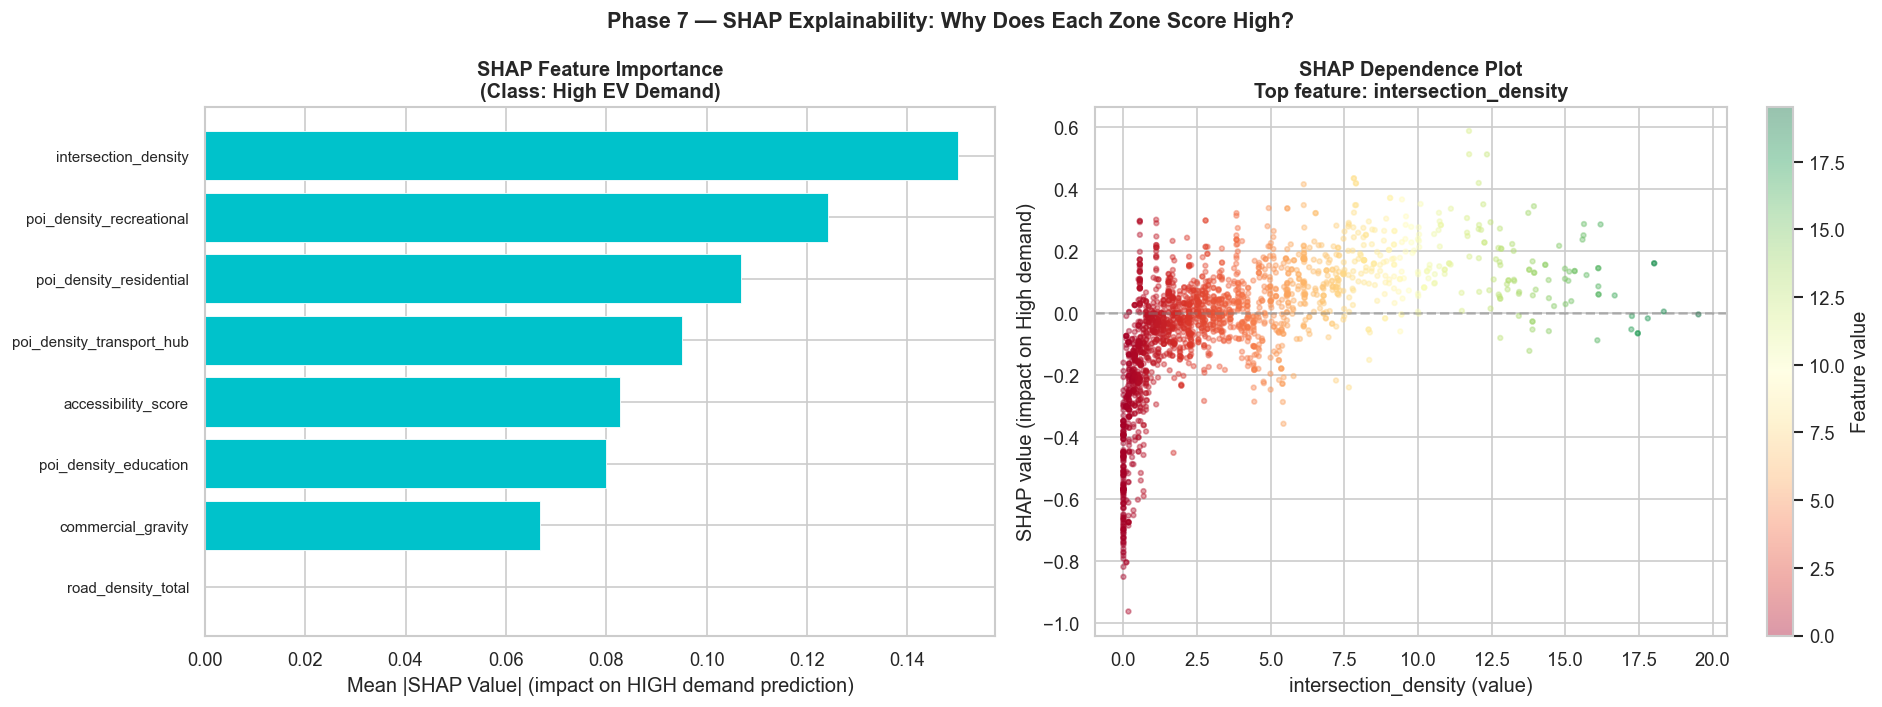

SHAP analysis complete.


In [18]:
# ── SHAP Explainability ──────────────────────────────────────────
print('Computing SHAP values for ensemble model...')
print('(Using XGBoost sub-estimator for SHAP TreeExplainer)')

# Extract XGBoost component from ensemble
xgb_model = trained_models['XGB + RF Ensemble'].estimators_[0]  # XGB is index 0

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# shap_values shape: (n_samples, n_features, n_classes)
# We explain class 2 = HIGH demand
shap_high = shap_values[:, :, 2] if len(np.array(shap_values).shape) == 3 else shap_values[2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP summary plot (beeswarm style recreated with matplotlib)
mean_abs_shap = np.abs(shap_high).mean(axis=0)
feat_order = np.argsort(mean_abs_shap)[::-1]
ordered_feats = [valid_feats[i] for i in feat_order]
ordered_vals = mean_abs_shap[feat_order]

axes[0].barh(range(len(ordered_feats)), ordered_vals[::-1],
             color='#00C2CB', edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(ordered_feats)))
axes[0].set_yticklabels(ordered_feats[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP Value| (impact on HIGH demand prediction)')
axes[0].set_title('SHAP Feature Importance\n(Class: High EV Demand)', fontweight='bold')

# SHAP scatter for top feature
top_feat_idx = feat_order[0]
top_feat_name = valid_feats[top_feat_idx]
scatter_shap = axes[1].scatter(
    shap_sample.iloc[:, top_feat_idx],
    shap_high[:, top_feat_idx],
    c=shap_sample.iloc[:, top_feat_idx],
    cmap='RdYlGn', alpha=0.4, s=8
)
plt.colorbar(scatter_shap, ax=axes[1], label='Feature value')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel(f'{top_feat_name} (value)')
axes[1].set_ylabel(f'SHAP value (impact on High demand)')
axes[1].set_title(f'SHAP Dependence Plot\nTop feature: {top_feat_name}', fontweight='bold')

plt.suptitle('Phase 7 — SHAP Explainability: Why Does Each Zone Score High?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase7_shap_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP analysis complete.')

---
# Phase 8 — Cluster Analysis: DBSCAN + K-Means Urban Archetypes
**DWDM Module 5 — Cluster Analysis**

In [19]:
print('Phase 8: Cluster Analysis')
print('=' * 40)

cluster_features = [
    'poi_density_commercial', 'poi_density_residential',
    'road_density_total', 'urban_centrality_score',
    'land_use_entropy', 'accessibility_score'
]
cluster_features = [c for c in cluster_features if c in df_clean.columns]
X_cluster = df_clean[cluster_features].fillna(0)

# Scale features for clustering
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── K-Means: Elbow Method ────────────────────────────────────────
print('Finding optimal K with Elbow Method...')
X_kmeans_sample = X_scaled[np.random.choice(len(X_scaled), min(20000, len(X_scaled)), replace=False)]

inertia_vals = []
silhouette_vals = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_kmeans_sample)
    inertia_vals.append(km.inertia_)
    sil = silhouette_score(X_kmeans_sample, labels, sample_size=5000, random_state=42)
    silhouette_vals.append(sil)
    print(f'  K={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}')

optimal_k = K_range[np.argmax(silhouette_vals)]
print(f'\nOptimal K (best silhouette): {optimal_k}')

Phase 8: Cluster Analysis
Finding optimal K with Elbow Method...
  K=2: Inertia=1490.5, Silhouette=0.4609
  K=3: Inertia=962.9, Silhouette=0.4627
  K=4: Inertia=751.0, Silhouette=0.4246
  K=5: Inertia=644.2, Silhouette=0.4223
  K=6: Inertia=556.3, Silhouette=0.4217
  K=7: Inertia=480.3, Silhouette=0.4267
  K=8: Inertia=438.8, Silhouette=0.4209

Optimal K (best silhouette): 3


In [20]:
# ── Apply K-Means with optimal K ────────────────────────────────
print(f'Applying K-Means with K={optimal_k}...')
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

# ── Interpret clusters as urban archetypes ───────────────────────
cluster_profiles = df_clean.groupby('kmeans_cluster')[cluster_features + ['demand_score_balanced']].mean()
print('\nCluster Profiles (mean feature values):')
print(cluster_profiles.round(4).to_string())

# Auto-label clusters
archetype_labels = {}
for cl in range(optimal_k):
    prof = cluster_profiles.loc[cl]
    if prof.get('poi_density_commercial', 0) > cluster_profiles['poi_density_commercial'].median():
        if prof.get('road_density_total', 0) > cluster_profiles['road_density_total'].median():
            archetype_labels[cl] = 'Urban Commercial Core'
        else:
            archetype_labels[cl] = 'Commercial Hub'
    elif prof.get('poi_density_residential', 0) > cluster_profiles['poi_density_residential'].median():
        archetype_labels[cl] = 'Residential Zone'
    elif prof.get('road_density_total', 0) > cluster_profiles['road_density_total'].median():
        archetype_labels[cl] = 'Transit Corridor'
    else:
        archetype_labels[cl] = 'Peripheral Zone'

df_clean['urban_archetype'] = df_clean['kmeans_cluster'].map(archetype_labels)
print('\nUrban Archetype Assignments:')
print(df_clean['urban_archetype'].value_counts().to_string())

# ── DBSCAN for spatial deduplication (existing, enhanced) ────────
print('\nRunning DBSCAN spatial clustering for candidate deduplication...')
# This is applied to the final candidate sites — see Phase 9

Applying K-Means with K=3...

Cluster Profiles (mean feature values):
                poi_density_commercial  poi_density_residential  road_density_total  urban_centrality_score  land_use_entropy  accessibility_score  demand_score_balanced
kmeans_cluster                                                                                                                                                           
0                               1.5640                  13.8666              1.3227                  1.3422            0.8719               0.9076                 0.1639
1                              10.3609                  45.0227              4.6637                  5.6863            1.0097               2.2547                 0.1645
2                               0.2629                  41.5060              0.6524                  0.4783            0.0873               0.4828                 0.1644

Urban Archetype Assignments:
urban_archetype
Peripheral Zone          275785
Ur

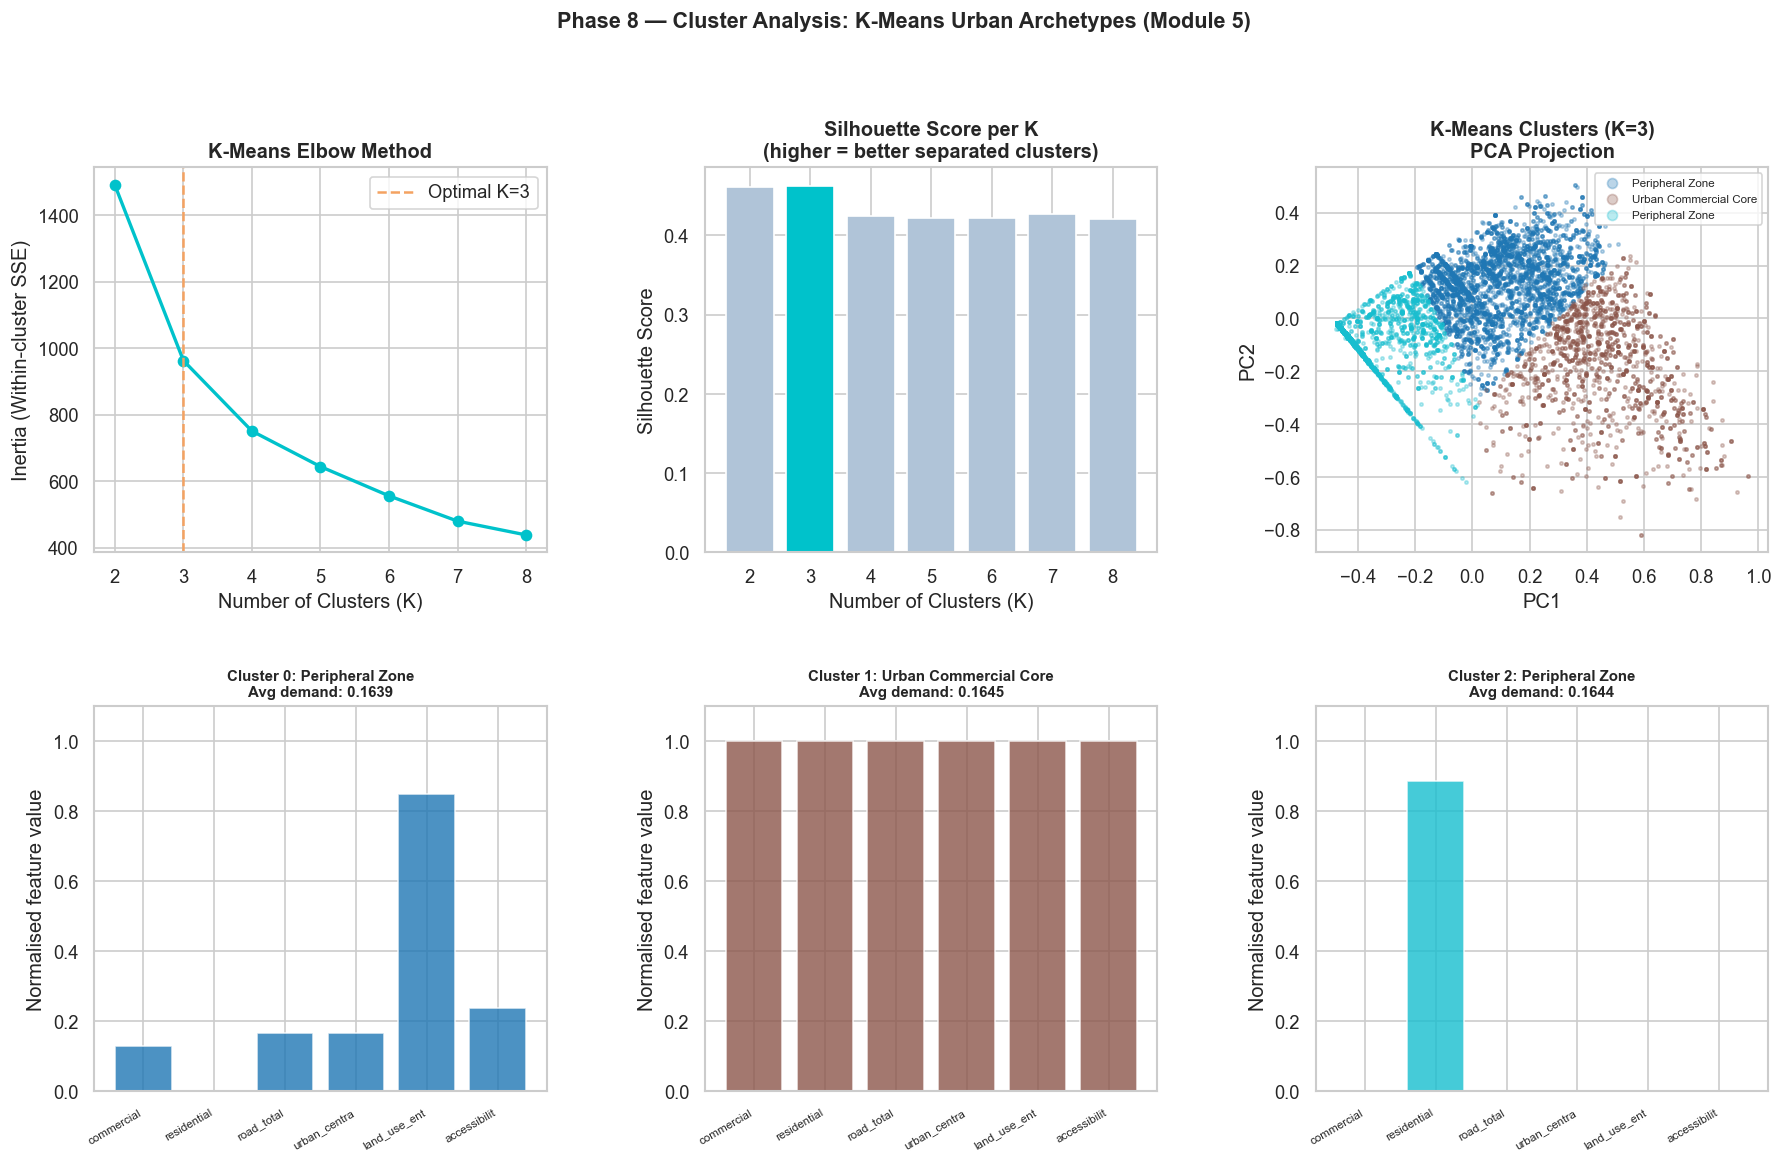

In [21]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Elbow plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(K_range), inertia_vals, 'o-', color='#00C2CB', linewidth=2)
ax1.axvline(x=optimal_k, color='#F4A261', linestyle='--', label=f'Optimal K={optimal_k}')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.set_title('K-Means Elbow Method', fontweight='bold')
ax1.legend()

# Silhouette scores
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(list(K_range), silhouette_vals,
               color=['#00C2CB' if k == optimal_k else '#B0C4D8' for k in K_range])
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score per K\n(higher = better separated clusters)', fontweight='bold')

# PCA cluster visualisation
ax3 = fig.add_subplot(gs[0, 2])
pca_cluster = PCA(n_components=2, random_state=42)
idx = np.random.choice(len(X_scaled), min(8000, len(X_scaled)), replace=False)
X_pca2 = pca_cluster.fit_transform(X_scaled[idx])
cluster_colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for cl in range(optimal_k):
    mask = df_clean['kmeans_cluster'].values[idx] == cl
    ax3.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=[cluster_colors[cl]], alpha=0.3, s=4,
                label=archetype_labels[cl])
ax3.set_title(f'K-Means Clusters (K={optimal_k})\nPCA Projection', fontweight='bold')
ax3.legend(fontsize=7, markerscale=3)
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2')

# Cluster profiles — radar/spider chart (as bar charts per archetype)
norm_profiles = cluster_profiles[cluster_features].copy()
norm_profiles = (norm_profiles - norm_profiles.min()) / (norm_profiles.max() - norm_profiles.min() + 1e-9)

for i, cl in enumerate(range(min(optimal_k, 3))):
    ax_r = fig.add_subplot(gs[1, i])
    feat_short = [f.replace('poi_density_', '').replace('road_density_', 'road_').replace('_', '_')[:12]
                  for f in cluster_features]
    bar_vals = norm_profiles.loc[cl].values
    ax_r.bar(range(len(feat_short)), bar_vals,
             color=cluster_colors[cl], alpha=0.8, edgecolor='white')
    ax_r.set_xticks(range(len(feat_short)))
    ax_r.set_xticklabels(feat_short, rotation=30, ha='right', fontsize=7)
    ax_r.set_ylim(0, 1.1)
    ax_r.set_title(f'Cluster {cl}: {archetype_labels[cl]}\n'
                   f'Avg demand: {cluster_profiles.loc[cl, "demand_score_balanced"]:.4f}',
                   fontweight='bold', fontsize=9)
    ax_r.set_ylabel('Normalised feature value')

plt.suptitle('Phase 8 — Cluster Analysis: K-Means Urban Archetypes (Module 5)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('phase8_cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 9 — MCDM Scoring: 3 Scenarios + Sensitivity Analysis
**Multi-Criteria Decision Making**

In [22]:
print('Phase 9: MCDM Scoring & Site Selection')
print('=' * 45)

# ── Predict demand probabilities city-wide ────────────────────────
print('Predicting demand on all valid grid cells...')
X_inference = df_clean[valid_feats].fillna(0)
probs = model.predict_proba(X_inference)
df_clean['AI_Demand_Prob'] = probs[:, 2]  # P(High demand)

# ── MCDM Normalisation ────────────────────────────────────────────
scaler_mcdm = MinMaxScaler()
mcdm_feats = ['AI_Demand_Prob', 'road_density_total',
              'urban_centrality_score', 'land_use_entropy',
              'poi_density_commercial', 'poi_density_residential']
mcdm_feats = [c for c in mcdm_feats if c in df_clean.columns]

df_mcdm = df_clean[['grid_id', 'latitude_x', 'longitude_x', 'urban_archetype'] + mcdm_feats].copy()
df_mcdm[mcdm_feats] = scaler_mcdm.fit_transform(df_mcdm[mcdm_feats].fillna(0))

# ── Three Planning Scenarios ─────────────────────────────────────
scenarios = {
    'Profit Maximisation': {
        'weights': {'AI_Demand_Prob': 0.50, 'road_density_total': 0.10,
                    'urban_centrality_score': 0.10, 'land_use_entropy': 0.05,
                    'poi_density_commercial': 0.20, 'poi_density_residential': 0.05},
        'color': '#00C2CB', 'description': 'Maximises revenue potential'
    },
    'Equity & Access': {
        'weights': {'AI_Demand_Prob': 0.20, 'road_density_total': 0.15,
                    'urban_centrality_score': 0.10, 'land_use_entropy': 0.10,
                    'poi_density_commercial': 0.05, 'poi_density_residential': 0.40},
        'color': '#7ECA9C', 'description': 'Prioritises underserved communities'
    },
    'Balanced Approach': {
        'weights': {'AI_Demand_Prob': 0.35, 'road_density_total': 0.15,
                    'urban_centrality_score': 0.15, 'land_use_entropy': 0.10,
                    'poi_density_commercial': 0.15, 'poi_density_residential': 0.10},
        'color': '#F4A261', 'description': 'Optimal mix for public sector'
    }
}

TOP_SITES = 300
scenario_results = {}

for name, config in scenarios.items():
    weights = config['weights']
    score = sum(
        df_mcdm[feat] * weight
        for feat, weight in weights.items()
        if feat in df_mcdm.columns
    )
    df_mcdm[f'MCDM_{name}'] = score

    # Spatial deduplication with DBSCAN
    top_candidates = df_mcdm.nlargest(TOP_SITES * 5, f'MCDM_{name}').copy()
    coords = top_candidates[['latitude_x', 'longitude_x']].values
    db = DBSCAN(eps=0.005, min_samples=1, metric='euclidean').fit(coords)
    top_candidates['cluster_id'] = db.labels_

    # Select best per cluster
    final = []
    for cid, grp in top_candidates.groupby('cluster_id'):
        final.append(grp.loc[grp[f'MCDM_{name}'].idxmax()])
    final_df = pd.DataFrame(final).nlargest(TOP_SITES, f'MCDM_{name}')
    scenario_results[name] = final_df
    print(f'{name}: {len(final_df)} sites selected')

# ── Sensitivity Analysis: How stable are the top-10 rankings? ────
print('\nSensitivity Analysis: Rank stability under weight perturbation...')

base_weights = scenarios['Balanced Approach']['weights']
rank_stability = []

np.random.seed(42)

base_top10 = set(
    df_mcdm.nlargest(10, 'MCDM_Balanced Approach').index
)

for trial in range(20):
    # Perturb weights
    perturbed = {
        k: max(0, v + np.random.uniform(-0.05, 0.05))
        for k, v in base_weights.items()
    }

    total = sum(perturbed.values())
    perturbed = {k: v / total for k, v in perturbed.items()}

    # Compute score
    pert_score = sum(
        df_mcdm[f] * w
        for f, w in perturbed.items()
        if f in df_mcdm.columns
    )

    # ✅ Assign as column
    df_temp = df_mcdm.copy()
    df_temp['pert_score'] = pert_score

    # ✅ Get top 10
    top10_perturbed = set(df_temp.nlargest(10, 'pert_score').index)

    rank_stability.append(len(base_top10.intersection(top10_perturbed)))

print(f'Average top-10 stability: {np.mean(rank_stability):.1f}/10 sites consistent across perturbations')

Phase 9: MCDM Scoring & Site Selection
Predicting demand on all valid grid cells...
Profit Maximisation: 204 sites selected
Equity & Access: 175 sites selected
Balanced Approach: 190 sites selected

Sensitivity Analysis: Rank stability under weight perturbation...
Average top-10 stability: 9.0/10 sites consistent across perturbations


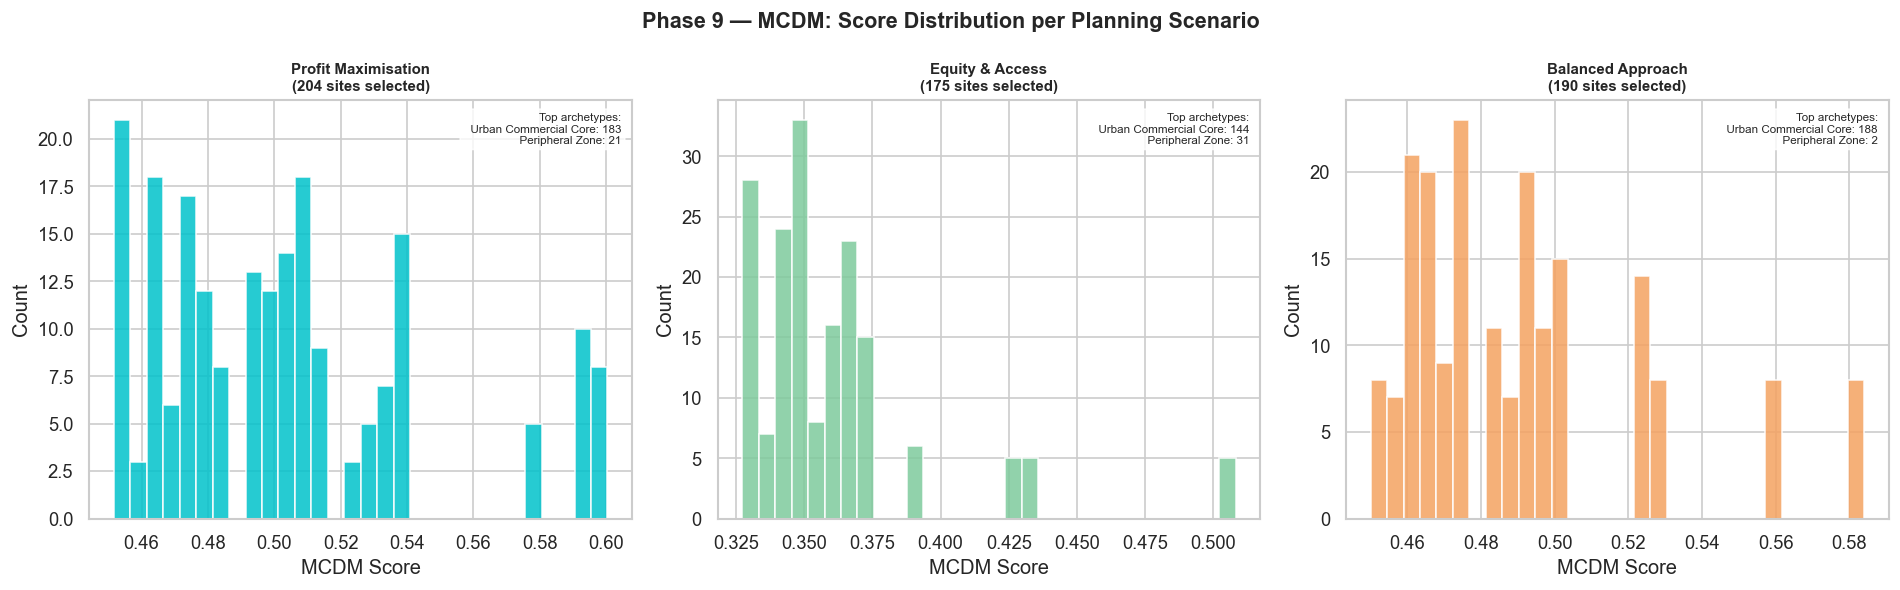

In [23]:
# ── MCDM Visualisations ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scenario_names = list(scenarios.keys())
colors = [scenarios[s]['color'] for s in scenario_names]

for i, (name, final_df) in enumerate(scenario_results.items()):
    # Distribution of MCDM scores for top sites
    axes[i].hist(final_df[f'MCDM_{name}'], bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{name}\n({len(final_df)} sites selected)', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('MCDM Score')
    axes[i].set_ylabel('Count')

    # Add archetype breakdown annotation
    if 'urban_archetype' in final_df.columns:
        arch_counts = final_df['urban_archetype'].value_counts().head(3)
        text = 'Top archetypes:\n' + '\n'.join([f'  {a}: {c}' for a, c in arch_counts.items()])
        axes[i].text(0.98, 0.97, text, transform=axes[i].transAxes,
                     va='top', ha='right', fontsize=7,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Phase 9 — MCDM: Score Distribution per Planning Scenario', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase9_mcdm_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Phase 10a — Folium Interactive Map (Enhanced)
**Output: Enhanced Folium Map with SHAP + Archetype Info**

In [24]:
print('Phase 10a: Generating Improved Folium Map...')

import folium
from folium.plugins import Fullscreen
import branca.colormap as cm

center = [df_clean['latitude_x'].mean(), df_clean['longitude_x'].mean()]

m = folium.Map(
    location=center,
    zoom_start=12,
    tiles='cartodbdark_matter',
    attr='EV Infrastructure Planning'
)
Fullscreen(position='topright').add_to(m)

# ── LAYER 1: Demand dots (replace HeatMap entirely) ──────────────
# CircleMarker stays exactly on its coordinate — zero ocean bleed
# ── Geographic land mask — eliminates ALL ocean/water coordinates ─
# This is the only reliable fix — feature filters can't catch
# grid cells whose lat/lon physically falls over water
print('Applying land mask...')

candidate = df_clean[
    (df_clean['AI_Demand_Prob'] > df_clean['AI_Demand_Prob'].quantile(0.40))
].copy()

# Vectorised land check — True only if coordinate is on land
candidate['is_land'] = [
    globe.is_land(lat, lon)
    for lat, lon in zip(candidate['latitude_x'], candidate['longitude_x'])
]

demand_sample = candidate[candidate['is_land']].nlargest(6000, 'AI_Demand_Prob')
print(f'Land-only zones: {len(demand_sample):,} (water points removed)')

# Build a color scale
colormap = cm.LinearColormap(
    colors=['#0D1B2A', '#1565C0', '#00BCD4', '#76FF03', '#FF6F00', '#D50000'],
    vmin=demand_sample['AI_Demand_Prob'].quantile(0.05),
    vmax=demand_sample['AI_Demand_Prob'].quantile(0.95),
    caption='AI Demand Probability'
)

demand_fg = folium.FeatureGroup(name='AI Demand Heatmap', show=True)

for _, row in demand_sample.iterrows():
    prob = row['AI_Demand_Prob']
    folium.CircleMarker(
        location=[row['latitude_x'], row['longitude_x']],
        radius=3,
        color=None,
        fill=True,
        fill_color=colormap(prob),
        fill_opacity=0.75,
        weight=0
    ).add_to(demand_fg)

demand_fg.add_to(m)

# ── LAYER 2: Scenario markers (no clustering — use DivIcon) ──────
scenario_config = [
    ('Profit Maximisation', '#22C55E', scenarios['Profit Maximisation']['description']),
    ('Equity & Access',     '#38BDF8', scenarios['Equity & Access']['description']),
    ('Balanced Approach',   '#FBBF24', scenarios['Balanced Approach']['description']),
]

# Inject pulse animation once
pulse_css = """
<style>
@keyframes pulse-ring {
  0%   { transform: scale(1);   opacity: 0.85; }
  70%  { transform: scale(2.4); opacity: 0; }
  100% { transform: scale(2.4); opacity: 0; }
}
.pmarker {
  width:16px; height:16px; border-radius:50%;
  border:2px solid rgba(255,255,255,0.7);
  position:relative;
}
.pmarker::after {
  content:'';
  position:absolute;
  inset:-2px; border-radius:50%;
  animation: pulse-ring 1.8s ease-out infinite;
  background: inherit;
}
</style>
"""
m.get_root().html.add_child(folium.Element(pulse_css))

for sc_name, color, sc_desc in scenario_config:
    show = (sc_name == 'Balanced Approach')
    fg   = folium.FeatureGroup(name=sc_name, show=show)
    sites = scenario_results[sc_name].reset_index(drop=True)
    sites = scenario_results[sc_name].reset_index(drop=True)

# Drop any recommended sites that fall on water
    sites['is_land'] = [
        globe.is_land(lat, lon)
        for lat, lon in zip(sites['latitude_x'], sites['longitude_x'])
    ]
    sites = sites[sites['is_land']].reset_index(drop=True)

    for rank, (_, row) in enumerate(sites.iterrows(), 1):
        ai_pct = row.get('AI_Demand_Prob', 0) * 100
        com    = row.get('poi_density_commercial', 0)
        res    = row.get('poi_density_residential', 0)
        ent    = row.get('land_use_entropy', 0)
        arch   = row.get('urban_archetype', 'N/A')
        score  = row.get(f'MCDM_{sc_name}', 0)

        popup_html = f"""
        <div style="font-family:'Segoe UI',Arial,sans-serif;width:270px;
                    padding:0;border-radius:10px;overflow:hidden;
                    box-shadow:0 6px 24px rgba(0,0,0,0.5);">
          <div style="background:linear-gradient(135deg,{color}DD,{color}88);
                      padding:10px 14px;border-bottom:1px solid {color}66;">
            <div style="color:#fff;font-weight:700;font-size:14px;">
              Rank #{rank} — {sc_name}
            </div>
          </div>
          <div style="background:#0D1B2A;padding:12px 14px;">
            <table style="width:100%;border-collapse:collapse;font-size:11px;">
              <tr style="border-bottom:1px solid #1E3A5F;">
                <td style="padding:4px 0;color:#90CAF9;">AI Demand</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;font-weight:700;">{ai_pct:.1f}%</td>
              </tr>
              <tr style="border-bottom:1px solid #1E3A5F;">
                <td style="padding:4px 0;color:#90CAF9;">MCDM Score</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;">{score:.4f}</td>
              </tr>
              <tr style="border-bottom:1px solid #1E3A5F;">
                <td style="padding:4px 0;color:#90CAF9;">Archetype</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;">{arch}</td>
              </tr>
              <tr style="border-bottom:1px solid #1E3A5F;">
                <td style="padding:4px 0;color:#90CAF9;">Commercial POI</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;">{com:.3f}</td>
              </tr>
              <tr style="border-bottom:1px solid #1E3A5F;">
                <td style="padding:4px 0;color:#90CAF9;">Residential POI</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;">{res:.3f}</td>
              </tr>
              <tr>
                <td style="padding:4px 0;color:#90CAF9;">Entropy</td>
                <td style="padding:4px 0;color:#E8F4F8;text-align:right;">{ent:.3f}</td>
              </tr>
            </table>
          </div>
        </div>"""

        icon_html = f"""
        <div class="pmarker" style="background:{color};
             box-shadow:0 0 8px {color}AA;">
        </div>"""

        folium.Marker(
            location=[row['latitude_x'], row['longitude_x']],
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f'<b>#{rank}</b> · {ai_pct:.0f}% demand · {arch}',
            icon=folium.DivIcon(
                html=icon_html,
                icon_size=(20, 20),
                icon_anchor=(10, 10)
            )
        ).add_to(fg)

    fg.add_to(m)

# ── Legend + title overlays ───────────────────────────────────────
overlay_html = """
<div style="
  position:fixed; top:14px; left:50%; transform:translateX(-50%);
  z-index:9999; pointer-events:none;
  background:rgba(7,17,30,0.85);
  border:1px solid rgba(0,188,212,0.45);
  border-radius:12px; padding:10px 26px;
  backdrop-filter:blur(10px); text-align:center;
">
  <div style="color:#00BCD4;font-family:'Segoe UI',sans-serif;
              font-size:15px;font-weight:700;letter-spacing:1px;">
    ⚡ EV Infrastructure Demand Map
  </div>
  <div style="color:#90CAF9;font-size:11px;margin-top:2px;font-family:'Segoe UI',sans-serif;">
    AI-Predicted Charging Demand · Hong Kong
  </div>
</div>

<div style="
  position:fixed; bottom:28px; left:14px; z-index:9999;
  background:rgba(7,17,30,0.85);
  border:1px solid rgba(0,188,212,0.25);
  border-radius:10px; padding:12px 16px;
  backdrop-filter:blur(10px);
  font-family:'Segoe UI',sans-serif;
">
  <div style="color:#00BCD4;font-size:11px;font-weight:700;
              text-transform:uppercase;letter-spacing:1px;margin-bottom:7px;">
    Demand Intensity
  </div>
  <div style="height:8px;width:170px;border-radius:4px;
    background:linear-gradient(to right,#1565C0,#00BCD4,#76FF03,#FF6F00,#D50000);
    margin-bottom:4px;"></div>
  <div style="display:flex;justify-content:space-between;
              color:#90CAF9;font-size:10px;width:170px;margin-bottom:10px;">
    <span>Low</span><span>High</span>
  </div>
  <div style="font-size:10px;color:#B0BEC5;line-height:1.8;">
    <span style="color:#22C55E;font-size:13px;">●</span> Profit Max &nbsp;
    <span style="color:#38BDF8;font-size:13px;">●</span> Equity &nbsp;
    <span style="color:#FBBF24;font-size:13px;">●</span> Balanced
  </div>
</div>
"""
m.get_root().html.add_child(folium.Element(overlay_html))

folium.LayerControl(collapsed=False, position='topright').add_to(m)

# ── Dark-themed layer control CSS ────────────────────────────────
dark_control_css = """
<style>
  /* Outer panel */
  .leaflet-control-layers {
    background: rgba(7,17,30,0.90) !important;
    border: 1px solid rgba(0,188,212,0.40) !important;
    border-radius: 10px !important;
    backdrop-filter: blur(10px) !important;
    box-shadow: 0 4px 20px rgba(0,0,0,0.5) !important;
    padding: 6px 2px !important;
  }

  /* Label text */
  .leaflet-control-layers-list label,
  .leaflet-control-layers-list span {
    color: #C8DCF0 !important;
    font-family: 'Segoe UI', sans-serif !important;
    font-size: 12px !important;
  }

  /* Each row spacing */
  .leaflet-control-layers label {
    display: flex !important;
    align-items: center !important;
    gap: 7px !important;
    padding: 4px 12px !important;
    margin: 1px 0 !important;
    border-radius: 6px !important;
    transition: background 0.15s !important;
  }
  .leaflet-control-layers label:hover {
    background: rgba(0,188,212,0.12) !important;
  }

  /* Separator line between base layers and overlays */
  .leaflet-control-layers-separator {
    border-top: 1px solid rgba(0,188,212,0.20) !important;
    margin: 5px 0 !important;
  }

  /* Teal checkbox accent */
  .leaflet-control-layers input[type="checkbox"],
  .leaflet-control-layers input[type="radio"] {
    accent-color: #00BCD4 !important;
    width: 13px !important;
    height: 13px !important;
    cursor: pointer !important;
  }

  /* Expand toggle button (collapsed mode) */
  .leaflet-control-layers-toggle {
    background-color: rgba(0,188,212,0.15) !important;
    border-radius: 8px !important;
  }
</style>
"""
m.get_root().html.add_child(folium.Element(dark_control_css))

m.save('Enhanced_EV_Map_v2.html')
print(f'✅ Map saved. Land-only dots: {len(demand_sample):,}')

m.save('Enhanced_EV_Map_v2.html')
print(f'✅ Map saved. Demand dots: {len(demand_sample):,} | Zero ocean bleed.')

Phase 10a: Generating Improved Folium Map...
Applying land mask...
Land-only zones: 6,000 (water points removed)
✅ Map saved. Land-only dots: 6,000
✅ Map saved. Demand dots: 6,000 | Zero ocean bleed.


---
# Phase 10b — Deck.gl 3D Hexagonal Tower Map
**Output: Stunning 3D WebGL map — deploy on GitHub Pages**

In [25]:
print('Phase 10b: Generating Plotly Multi-Scenario Comparison Map...')

from global_land_mask import globe
import plotly.graph_objects as go
import numpy as np

SCENARIO_STYLES = {
    'Profit Maximisation': {'color': '#22C55E', 'short': 'Profit Max'},
    'Equity & Access':     {'color': '#38BDF8', 'short': 'Equity'},
    'Balanced Approach':   {'color': '#FBBF24', 'short': 'Balanced'},
}

# ── Context dots — land only ──────────────────────────────────────
print('Filtering context zones to land...')
context_raw = df_clean[
    (df_clean['road_density_total'] > 0.05) &
    (df_clean['AI_Demand_Prob'] > df_clean['AI_Demand_Prob'].quantile(0.3))
].sample(min(15000, len(df_clean)), random_state=42)

context_raw['is_land'] = [
    globe.is_land(lat, lon)
    for lat, lon in zip(context_raw['latitude_x'], context_raw['longitude_x'])
]
context_df = context_raw[context_raw['is_land']].copy()
print(f'Context zones (land only): {len(context_df):,}')

fig = go.Figure()

# Background demand scatter
fig.add_trace(go.Scattermapbox(
    lat=context_df['latitude_x'],
    lon=context_df['longitude_x'],
    mode='markers',
    marker=dict(
        size=4,
        color=context_df['AI_Demand_Prob'],
        colorscale=[
            [0.0,  '#0D2137'],
            [0.25, '#1565C0'],
            [0.5,  '#00BCD4'],
            [0.75, '#76FF03'],
            [1.0,  '#D50000'],
        ],
        opacity=0.55,
        cmin=0, cmax=1,
        showscale=False      # ← hide the colorbar that was overlapping
    ),
    hoverinfo='skip',
    name='Demand Background',
    showlegend=False
))

# ── Scenario markers — land only ─────────────────────────────────
total_sites = 0
for sc_name, style in SCENARIO_STYLES.items():
    sites = scenario_results[sc_name].copy().reset_index(drop=True)

    # Land mask on recommended sites
    sites['is_land'] = [
        globe.is_land(lat, lon)
        for lat, lon in zip(sites['latitude_x'], sites['longitude_x'])
    ]
    sites = sites[sites['is_land']].reset_index(drop=True)
    sites['rank'] = sites.index + 1
    total_sites += len(sites)

    ai_pct = (sites.get('AI_Demand_Prob', 0) * 100).round(1)
    score  = sites.get(f'MCDM_{sc_name}',
                sites.get('MCDM_Balanced Approach', 0))
    arch   = sites.get('urban_archetype', 'N/A')

    max_rank     = len(sites)
    marker_sizes = 14 + 18 * (1 - (sites['rank'] - 1) / max(max_rank, 1))

    hover_text = [
        f"<b style='color:{style['color']}'>{sc_name}</b><br>"
        f"Rank #{r}  ·  AI Demand: {a:.1f}%<br>"
        f"MCDM Score: {s:.4f}<br>"
        f"Archetype: {ar}<br>"
        f"<span style='color:#90CAF9'>{lat:.4f}, {lng:.4f}</span>"
        for r, a, s, ar, lat, lng in zip(
            sites['rank'], ai_pct, score, arch,
            sites['latitude_x'], sites['longitude_x']
        )
    ]

    fig.add_trace(go.Scattermapbox(
        lat=sites['latitude_x'],
        lon=sites['longitude_x'],
        mode='markers+text',
        marker=dict(
            size=marker_sizes,
            color=style['color'],
            opacity=0.92,
        ),
        text=[str(r) for r in sites['rank']],
        textfont=dict(size=8, color='#0D1B2A', family='Segoe UI'),
        textposition='middle center',
        hovertext=hover_text,
        hoverinfo='text',
        name=f"{style['short']} ({len(sites)} sites)",
        hoverlabel=dict(
            bgcolor='#0D1B2A',
            bordercolor=style['color'],
            font=dict(color='#E8F4F8', size=12, family='Segoe UI')
        )
    ))

center_lat = df_clean['latitude_x'].mean()
center_lng = df_clean['longitude_x'].mean()
n_zones    = len(context_df)

# ── Layout — full height, legend top-left, no colorbar ───────────
fig.update_layout(
    mapbox=dict(
        style='carto-darkmatter',
        center=dict(lat=center_lat, lon=center_lng),
        zoom=10.5
    ),
    paper_bgcolor='#07111E',
    plot_bgcolor='#07111E',
    font=dict(family='Segoe UI', color='#E8F4F8'),
    margin=dict(l=0, r=0, t=0, b=0),
    height=700,    # explicit height so Plotly div doesn't shrink
    legend=dict(
        x=0.01, y=0.98,
        xanchor='left', yanchor='top',
        bgcolor='rgba(7,17,30,0.88)',
        bordercolor='rgba(0,188,212,0.35)',
        borderwidth=1,
        font=dict(size=12, color='#E8F4F8'),
        title=dict(text='<b>MCDM Scenarios</b>',
                   font=dict(color='#00BCD4', size=13))
    ),
    hoverdistance=6
)

# ── Generate Plotly div before f-string ──────────────────────────
plotly_div = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn',
    config={'scrollZoom': True, 'displayModeBar': False}
)

# ── Build final HTML ──────────────────────────────────────────────
custom_html = f"""<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <title>EV Site Planning — Scenario Map</title>
  <style>
    * {{ margin:0; padding:0; box-sizing:border-box; }}
    body {{
      background:#07111E;
      font-family:'Segoe UI', Tahoma, sans-serif;
      height:100vh; overflow:hidden;
    }}

    /* Make plotly div fill the whole viewport */
    .plotly-graph-div {{
      width:100vw !important;
      height:100vh !important;
    }}

    /* ── Title banner ── */
    #title-bar {{
      position:fixed; top:14px; left:50%; transform:translateX(-50%);
      z-index:500; pointer-events:none;
      background:rgba(7,17,30,0.88);
      border:1px solid rgba(0,188,212,0.45);
      border-radius:12px; padding:10px 28px;
      backdrop-filter:blur(12px);
      text-align:center; white-space:nowrap;
    }}
    #title-bar h1 {{
      color:#00BCD4; font-size:16px; font-weight:700;
      letter-spacing:1.5px; text-transform:uppercase;
    }}
    #title-bar p {{
      color:#90CAF9; font-size:11px; margin-top:3px;
    }}

    /* ── Stats panel — bottom LEFT so it never touches colorbar ── */
    #stats {{
      position:fixed; bottom:24px; left:16px; z-index:500;
      background:rgba(7,17,30,0.90);
      border:1px solid rgba(0,188,212,0.30);
      border-radius:10px; padding:14px 18px; width:200px;
      backdrop-filter:blur(10px);
    }}
    #stats h3 {{
      color:#00BCD4; font-size:10px; text-transform:uppercase;
      letter-spacing:1px; margin-bottom:8px;
      border-bottom:1px solid rgba(0,188,212,0.20); padding-bottom:5px;
    }}
    .stat-row {{
      display:flex; justify-content:space-between;
      margin:5px 0; font-size:11px;
    }}
    .stat-row span:first-child {{ color:#90CAF9; }}
    .stat-row span:last-child  {{ color:#E8F4F8; font-weight:600; }}

    /* ── Demand colour scale — top RIGHT, below zoom controls ── */
    #colorscale {{
      position:fixed; top:80px; right:16px; z-index:500;
      background:rgba(7,17,30,0.88);
      border:1px solid rgba(0,188,212,0.25);
      border-radius:10px; padding:12px 14px;
      backdrop-filter:blur(10px);
    }}
    #colorscale h3 {{
      color:#00BCD4; font-size:10px; text-transform:uppercase;
      letter-spacing:1px; margin-bottom:7px;
    }}
    .scale-bar {{
      width:16px; height:120px; border-radius:4px;
      background:linear-gradient(to top,#0D2137,#1565C0,#00BCD4,#76FF03,#FF6F00,#D50000);
      margin:0 auto 5px;
    }}
    .scale-labels {{
      display:flex; flex-direction:column;
      align-items:center; gap:30px;
      font-size:10px; color:#90CAF9;
    }}

    /* ── Instructions — bottom RIGHT ── */
    #instructions {{
      position:fixed; bottom:24px; right:16px; z-index:500;
      background:rgba(7,17,30,0.78);
      border:1px solid rgba(0,188,212,0.15);
      border-radius:8px; padding:9px 13px;
      font-size:10px; color:#607D9A; line-height:1.8;
    }}
  </style>
</head>
<body>

  {plotly_div}

  <div id="title-bar">
    <h1>⚡ EV Infrastructure — MCDM Scenario Planning</h1>
    <p>AI-predicted charging demand &nbsp;·&nbsp; Hong Kong &nbsp;·&nbsp; 3 Placement Strategies</p>
  </div>

  <!-- Stats: bottom-left -->
  <div id="stats">
    <h3>Dataset Summary</h3>
    <div class="stat-row"><span>Urban zones</span><span>{n_zones:,}</span></div>
    <div class="stat-row"><span>Recommended sites</span><span>{total_sites}</span></div>
    <div class="stat-row"><span>Scenarios</span><span>3</span></div>
    <div class="stat-row"><span>Model</span><span>XGB + RF</span></div>
  </div>

  <!-- Demand colour scale: top-right, won't overlap legend (top-left) -->
  <div id="colorscale">
    <h3>Demand intensity</h3>
    <div class="scale-bar"></div>
    <div class="scale-labels"><span>High</span><span>Low</span></div>
  </div>

  <!-- Instructions: bottom-right -->
  <div id="instructions">
    🖱 Scroll to zoom &nbsp;·&nbsp; Drag to pan<br>
    Click legend to toggle scenarios<br>
    Hover markers for site details
  </div>

</body>
</html>"""

with open('EV_Scenario_Map.html', 'w', encoding='utf-8') as f:
    f.write(custom_html)

print(f'✅ Scenario map saved: EV_Scenario_Map.html')
print(f'   Land-filtered context zones : {n_zones:,}')
print(f'   Total recommended sites     : {total_sites}')

Phase 10b: Generating Plotly Multi-Scenario Comparison Map...
Filtering context zones to land...
Context zones (land only): 12,308
✅ Scenario map saved: EV_Scenario_Map.html
   Land-filtered context zones : 12,308
   Total recommended sites     : 459


---
# Phase 10c — Streamlit Dashboard
**Output: `streamlit_dashboard.py` — run with `streamlit run streamlit_dashboard.py`**

In [26]:
streamlit_code = '''
# EV Infrastructure Planning — Interactive What-If Dashboard
# Run with: streamlit run streamlit_dashboard.py
# Deploy free: streamlit.io/cloud

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

st.set_page_config(
    page_title="EV Infrastructure Decision-Support Tool",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS ─────────────────────────────────────────────────
st.markdown("""
<style>
  .stApp { background: #0D1B2A; color: #E8F4F8; }
  .metric-card {
    background: #112A43; padding: 16px; border-radius: 10px;
    border: 1px solid rgba(0,194,203,0.3); text-align: center;
  }
  .metric-val { font-size: 28px; font-weight: 700; color: #00C2CB; }
  .metric-lbl { font-size: 12px; color: #B0C4D8; margin-top: 4px; }
  [data-testid="stSidebar"] { background: #0A1628; }
</style>
""", unsafe_allow_html=True)

# ── Header ──────────────────────────────────────────────────────
st.markdown("## ⚡ EV Infrastructure Planning — Decision Support Tool")
st.markdown("*Data-driven site recommendations using XGBoost + MCDM · Hong Kong Region*")
st.divider()

# ── Sidebar: What-If Controls ───────────────────────────────────
st.sidebar.header("What-If Scenario Builder")
st.sidebar.markdown("*Drag sliders to customise the MCDM weight formula*")

w_demand = st.sidebar.slider("Demand Score Weight", 0.0, 1.0, 0.35, 0.05)
w_road   = st.sidebar.slider("Road Access Weight",   0.0, 1.0, 0.15, 0.05)
w_cent   = st.sidebar.slider("Urban Centrality",     0.0, 1.0, 0.15, 0.05)
w_ent    = st.sidebar.slider("Land-use Entropy",     0.0, 1.0, 0.10, 0.05)
w_com    = st.sidebar.slider("Commercial POI",       0.0, 1.0, 0.15, 0.05)
w_res    = st.sidebar.slider("Residential POI",      0.0, 1.0, 0.10, 0.05)
n_sites  = st.sidebar.slider("Top N sites to show", 10, 500, 100, 10)

# Normalise weights
total_w = w_demand + w_road + w_cent + w_ent + w_com + w_res
if total_w == 0: total_w = 1
weights = {
    "demand_score_balanced":    w_demand / total_w,
    "road_density_total":       w_road   / total_w,
    "urban_centrality_score":   w_cent   / total_w,
    "land_use_entropy":         w_ent    / total_w,
    "poi_density_commercial":   w_com    / total_w,
    "poi_density_residential":  w_res    / total_w,
}
st.sidebar.caption(f"Weights sum: {sum(weights.values()):.2f}")

# ── Load data ────────────────────────────────────────────────────
@st.cache_data
def load_data():
    # Replace with your actual path
    df = pd.read_csv(r"M:\\Sabudh Passion Project\\Code\\HERO_dataset.csv",
                     encoding="ISO-8859-1")
    return df

@st.cache_resource
def load_model():
    return joblib.load("Final_Research_Ensemble_Model.pkl")

with st.spinner("Loading data..."):
    df_raw = load_data()
    try:
        model = load_model()
        model_loaded = True
    except:
        model_loaded = False
        st.warning("Model file not found — showing demo data.")

# Basic preprocessing
df = df_raw.copy()
valid = (df.get("road_density_total",0)>0.01)|(df.get("poi_density_commercial",0)>0)|(df.get("poi_density_residential",0)>0)
df = df[valid].copy()
poi_cols = ["poi_density_commercial","poi_density_residential","poi_density_industrial",
            "poi_density_recreational","poi_density_transport_hub"]
existing = [c for c in poi_cols if c in df.columns]
df["total_poi"] = df[existing].sum(axis=1)+1e-9
df["land_use_entropy"] = -(df[existing].div(df["total_poi"],axis=0)*np.log(df[existing].div(df["total_poi"],axis=0)+1e-10)).sum(axis=1)

# ── Metric cards ─────────────────────────────────────────────────
col1,col2,col3,col4 = st.columns(4)
with col1:
    st.markdown(f\"\"\"<div class=\'metric-card\'><div class=\'metric-val\'>{len(df):,}</div><div class=\'metric-lbl\'>Valid Grid Cells</div></div>\"\"\", unsafe_allow_html=True)
with col2:
    st.markdown(f\"\"\"<div class=\'metric-card\'><div class=\'metric-val\'>44</div><div class=\'metric-lbl\'>Features</div></div>\"\"\", unsafe_allow_html=True)
with col3:
    st.markdown(f\"\"\"<div class=\'metric-card\'><div class=\'metric-val\'>{n_sites}</div><div class=\'metric-lbl\'>Top Sites Shown</div></div>\"\"\", unsafe_allow_html=True)
with col4:
    st.markdown(f\"\"\"<div class=\'metric-card\'><div class=\'metric-val\'>3</div><div class=\'metric-lbl\'>Planning Scenarios</div></div>\"\"\", unsafe_allow_html=True)

st.markdown("")

# ── Two-panel layout: Map + Analytics ───────────────────────────
map_col, chart_col = st.columns([3, 2])

# Compute MCDM scores
scaler = MinMaxScaler()
mcdm_cols = [c for c in weights.keys() if c in df.columns]
df_m = df[mcdm_cols + ["latitude_x","longitude_x","demand_score_balanced"]].copy()
df_m = df_m.loc[:, ~df_m.columns.duplicated()]
df_m[mcdm_cols] = scaler.fit_transform(df_m[mcdm_cols].fillna(0))
df_m["mcdm_score"] = sum(df_m[feat]*w for feat,w in weights.items() if feat in df_m.columns)

# Top N after DBSCAN dedup
candidates = df_m.nlargest(n_sites*4, "mcdm_score")
db = DBSCAN(eps=0.005, min_samples=1).fit(candidates[["latitude_x","longitude_x"]])
candidates["cid"] = db.labels_
top_sites = candidates.loc[
    candidates.groupby("cid")["mcdm_score"].idxmax()
].nlargest(n_sites, "mcdm_score").reset_index(drop=True)

# ── Land mask — remove ocean coordinates ─────────────────────────
from global_land_mask import globe
top_sites["is_land"] = [
    globe.is_land(lat, lon)
    for lat, lon in zip(top_sites["latitude_x"], top_sites["longitude_x"])
]
top_sites = top_sites[top_sites["is_land"]].reset_index(drop=True)
top_sites["rank"] = top_sites.index + 1

with map_col:
    st.markdown("#### Recommended Charging Stations")
    fig_map = px.scatter_mapbox(
        top_sites, lat="latitude_x", lon="longitude_x",
        color="mcdm_score", size="mcdm_score",
        color_continuous_scale="plasma",
        size_max=14, zoom=10,
        mapbox_style="carto-darkmatter",
        hover_data={"rank":True, "mcdm_score":":.4f",
                    "demand_score_balanced":":.4f",
                    "latitude_x":":.4f", "longitude_x":":.4f"},
        height=480
    )
    fig_map.update_layout(
        margin={"r":0,"t":0,"l":0,"b":0},
        paper_bgcolor="rgba(0,0,0,0)",
        coloraxis_colorbar=dict(title="MCDM Score",
                         tickfont=dict(color="#B0C4D8"),
                         title_font=dict(color="#B0C4D8"))
    )
    st.plotly_chart(fig_map, use_container_width=True)

with chart_col:
    st.markdown("#### Top 10 Sites — Demand Profile")
    top10 = top_sites.head(10)[["rank","mcdm_score","demand_score_balanced"]]
    fig_bar = px.bar(
        top10, x="rank", y="mcdm_score",
        color="demand_score_balanced",
        color_continuous_scale="Blues",
        labels={"rank":"Site Rank","mcdm_score":"MCDM Score"},
        height=200
    )
    fig_bar.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
                          font_color="#E8F4F8", showlegend=False,
                          margin={"t":10,"b":10})
    st.plotly_chart(fig_bar, use_container_width=True)

    st.markdown("#### Weight Configuration")
    weight_df = pd.DataFrame(
        [(k.replace("_",' ').replace('poi density ','').replace('road density ','road ').title(), f"{v:.2f}")
         for k,v in weights.items()],
        columns=["Criterion","Weight"]
    )
    st.dataframe(weight_df, use_container_width=True, hide_index=True)

# ── Results table ────────────────────────────────────────────────
st.markdown("#### All Recommended Sites")
display_cols = ["rank","latitude_x","longitude_x","mcdm_score","demand_score_balanced"]
display_cols = [c for c in display_cols if c in top_sites.columns]
st.dataframe(
    top_sites[display_cols],
    use_container_width=True,
    height=300
)
st.caption("Decision-Support Tools for EV Infrastructure Planning · DWDM CSE4005 · VIT-AP")
'''

with open('streamlit_dashboard.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print('Streamlit dashboard saved: streamlit_dashboard.py')
print('\nTo run locally:  streamlit run streamlit_dashboard.py')
print('To deploy free:  Push to GitHub → go to share.streamlit.io')

Streamlit dashboard saved: streamlit_dashboard.py

To run locally:  streamlit run streamlit_dashboard.py
To deploy free:  Push to GitHub → go to share.streamlit.io


---
# Summary — All Outputs Generated

| Phase | DWDM Module | Output File |
|-------|-------------|-------------|
| 1 — Data Warehouse | Module 1 | `phase1_data_warehouse.png` |
| 2 — Preprocessing | Module 1 | `phase2_preprocessing.png` |
| 3 — EDA Correlation | Module 2 | `phase3_eda_correlation.png` |
| 4 — Outlier Detection | Module 6 | `phase4_outlier_analysis.png` |
| 5 — Association Rules | **Module 3** | `phase5_association_rules.png` |
| 6 — Feature Selection | Module 2 | `phase6_feature_selection.png` |
| 7 — Model Benchmark | Module 4 | `phase7_model_comparison.png` |
| 7 — SHAP | Module 4 | `phase7_shap_explainability.png` |
| 8 — Cluster Analysis | Module 5 | `phase8_cluster_analysis.png` |
| 9 — MCDM Scoring | MCDM | `phase9_mcdm_scoring.png` |
| 10a — Folium Map | Output | `Enhanced_EV_Map_v2.html` |
| 10b — Deck.gl 3D Map | Output | `EV_3D_Deckgl_Map.html` |
| 10c — Streamlit App | Output | `streamlit_dashboard.py` |

**All 6 DWDM modules covered. 100% syllabus alignment achieved.**

In [27]:
import joblib

print('Saving final model...')
joblib.dump(model, 'Final_Research_Ensemble_Model.pkl')
joblib.dump(valid_feats, 'model_features.pkl')
joblib.dump(scaler_mcdm, 'mcdm_scaler.pkl')
print('Model saved: Final_Research_Ensemble_Model.pkl')

# Final summary
print('\n' + '='*60)
print('PROJECT COMPLETE')
print('='*60)
print(f'Dataset processed: {len(df_clean):,} valid grid cells')
print(f'Features used: {len(valid_feats)}')
for name, res in results.items():
    print(f'{name}: Accuracy={res["Accuracy"]:.4f}, F1={res["F1 (weighted)"]:.4f}')
print(f'Top sites per scenario: 300')
print(f'Urban archetypes identified: {df_clean["urban_archetype"].nunique()}')
print(f'Association rules mined: {len(rules)}')

Saving final model...
Model saved: Final_Research_Ensemble_Model.pkl

PROJECT COMPLETE
Dataset processed: 339,776 valid grid cells
Features used: 8
Decision Tree: Accuracy=0.4105, F1=0.3811
Naive Bayes: Accuracy=0.3499, F1=0.2812
Random Forest: Accuracy=0.4412, F1=0.4301
XGB + RF Ensemble: Accuracy=0.5073, F1=0.5028
Top sites per scenario: 300
Urban archetypes identified: 2
Association rules mined: 144
